In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from google.colab import files
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

In [2]:
df1 = pd.read_csv('fb_data_new(4).csv')
df1.head()

,url,text,likes,comments1,comments,shares_n,shares_t,shares,time,sf,...,start date,d date,page active,person,plant,cluster1,cluster2,cluster3,pfr,sfr
0,https://www.facebook.com/IKEAIndia/posts/pfbid...,"A weekend of connection, conversations, belong...",26,0,0,0,95,47.0,18,0,...,11-05-2009,16-03-2026,6153,0,1,NaN,1,1,0,0
1,https://www.facebook.com/Pepperfry/posts/pfbid...,"This Women’s Day, give your home a smart upgra...",27,41,41,19,0,0.0,18,0,...,02-10-2001,16-03-2026,8931,0,1,NaN,1,0,0,0
2,https://www.facebook.com/Pepperfry/posts/pfbid...,"If not on a Tuesday, then when?🪧🏴🕯️\n\n#pepper...",17,41,41,37,0,0.0,26,0,...,02-10-2001,16-03-2026,8931,0,0,NaN,1,1,0,0
3,https://www.facebook.com/Pepperfry/posts/pfbid...,From the hands that craft it with care to the ...,17,41,41,1,89,44.0,45,0,...,02-10-2001,16-03-2026,8931,0,1,NaN,1,0,0,0
4,https://www.facebook.com/wayfair/posts/pfbid02...,Our 72-Hour Clearout is BACK ⏰ ❄️ 📆 Save up to...,76,33,33,3,0,0.0,57,0,...,25-08-2011,16-03-2026,5317,0,1,NaN,0,0,0,0


In [3]:
# Calculate and display descriptive statistics for the DataFrame
s1=df1.describe()

In [4]:
display(s1)

,likes,comments1,comments,shares_n,shares_t,shares,time,sf,pf,saturation,...,post_interval,revenue,page active,person,plant,cluster1,cluster2,cluster3,pfr,sfr
count,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,...,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,0.0,2191.000000,2191.000000,2191.000000,2191.000000
mean,61.014149,35.855774,35.996349,13.614788,26.103149,20.901552,383.238247,3.863989,1.712460,56.933364,...,3.584665,4.136438,5749.580557,0.482428,0.504336,NaN,0.502510,0.485623,1.675491,3.829302
std,329.668500,63.076023,63.154923,24.427760,36.379611,26.257562,373.904780,3.093480,1.692429,44.167584,...,4.936031,2.271682,1444.268133,0.499805,0.500095,NaN,0.500108,0.499907,1.614188,3.057154
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,-7.000000,1.450000,2880.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
25%,10.000000,4.000000,4.000000,1.000000,0.000000,0.000000,145.000000,1.000000,1.000000,25.000000,...,2.000000,1.931496,5317.000000,0.000000,0.000000,NaN,0.000000,0.000000,1.000000,1.000000
50%,23.000000,29.000000,29.000000,2.000000,10.000000,9.000000,302.000000,3.000000,1.000000,47.000000,...,2.000000,3.867962,5534.000000,0.000000,1.000000,NaN,1.000000,0.000000,1.000000,3.000000
75%,47.500000,45.000000,45.000000,15.000000,43.000000,36.000000,477.000000,6.000000,3.000000,78.500000,...,4.000000,5.704363,6276.000000,1.000000,1.000000,NaN,1.000000,1.000000,2.000000,6.000000
max,10000.000000,573.000000,573.000000,388.000000,282.000000,149.000000,2391.000000,18.000000,19.000000,255.000000,...,91.000000,9.120000,8931.000000,1.000000,1.000000,NaN,1.000000,1.000000,17.000000,17.000000


In [5]:
r1=s1[['time', 'logwc',  'saturation', 'post_interval']]

In [6]:
display(r1[['time', 'logwc',  'saturation', 'post_interval']])

,time,logwc,saturation,post_interval
count,2191.000000,2191.000000,2191.000000,2191.000000
mean,383.238247,3.380158,56.933364,3.584665
std,373.904780,0.885809,44.167584,4.936031
min,1.000000,0.000000,0.000000,-7.000000
25%,145.000000,3.044522,25.000000,2.000000
50%,302.000000,3.496508,47.000000,2.000000
75%,477.000000,3.912023,78.500000,4.000000
max,2391.000000,5.220356,255.000000,91.000000


In [7]:
mean_values = s1.loc['mean']
display(mean_values)

,mean
likes,61.014149
comments1,35.855774
comments,35.996349
shares_n,13.614788
shares_t,26.103149
shares,20.901552
time,383.238247
sf,3.863989
pf,1.712460
saturation,56.933364


In [8]:
smean_r1 = r1.loc['mean'].sum()
print(f"Sum of the mean of all columns in r1: {smean_r1}")

Sum of the mean of all columns in r1: 447.1364337250634


In [9]:
r2=s1[['revenue']]

In [10]:
display(r2)

,revenue
count,2191.000000
mean,4.136438
std,2.271682
min,1.450000
25%,1.931496
50%,3.867962
75%,5.704363
max,9.120000


In [11]:
r3=s1[['page active']]

In [12]:
display(r3)

,page active
count,2191.000000
mean,5749.580557
std,1444.268133
min,2880.000000
25%,5317.000000
50%,5534.000000
75%,6276.000000
max,8931.000000


In [13]:
col= ['likes', 'shares', 'comments', 'pf', 'sf', 'saturation', 'wc', 'logwc', 'post_interval','page active','revenue']
df1[col]

,likes,shares,comments,pf,sf,saturation,wc,logwc,post_interval,page active,revenue
0,26,47.0,0,0,0,25,12,2.484907,1,6153,1.450000
1,27,0.0,41,0,0,63,29,3.367296,1,8931,2.849599
2,17,0.0,41,0,0,58,29,3.367296,1,8931,2.386887
3,17,44.0,41,0,0,24,29,3.367296,1,8931,1.450000
4,76,0.0,33,0,0,32,19,2.944439,9,5317,1.745256
...,...,...,...,...,...,...,...,...,...,...,...
2186,2,0.0,40,13,6,49,37,3.610918,8,3708,1.450000
2187,2,45.0,0,13,7,138,31,3.433987,10,5534,1.450000
2188,211,0.0,10,14,0,20,42,3.737670,4,5423,7.722011
2189,6,48.0,41,15,4,0,53,3.970292,2,5402,1.499301


In [14]:
col1= ['shares', 'comments']
df1[col1]

,shares,comments
0,47.0,0
1,0.0,41
2,0.0,41
3,44.0,41
4,0.0,33
...,...,...
2186,0.0,40
2187,45.0,0
2188,0.0,10
2189,48.0,41


In [15]:
df1['sf2'] = df1['sf'] ** 2
df1['sf2'].head()

,sf2
0,0
1,0
2,0
3,0
4,0


In [16]:
mean_values = s1.loc['mean']
display(mean_values)

,mean
likes,61.014149
comments1,35.855774
comments,35.996349
shares_n,13.614788
shares_t,26.103149
shares,20.901552
time,383.238247
sf,3.863989
pf,1.712460
saturation,56.933364


REGRESSION MODEL WITH PRIMARY FEATURES

In [17]:
#REGRESSION MODEL WITH PRIMARY FEATURES

Y_shares = df1['shares']
X_var = ['time','logwc','pf','saturation','post_interval','revenue','page active']
X_shares = df1[X_var]

data_for_shares_model = pd.concat([Y_shares, X_shares], axis=1)
data_for_shares_model = data_for_shares_model.dropna(subset=['shares'] + X_var)
data_for_shares_model['shares'] = data_for_shares_model['shares'].astype(float).astype(int)

Y_clear = data_for_shares_model['shares']
X_clear = data_for_shares_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_shares = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_shares)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_shares_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_shares_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'shares': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'shares' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'shares' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                            shares   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2183
Method:                                      MLE   Df Model:                            7
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                0.005352
Time:                                   03:07:55   Log-Likelihood:                -6694.8
converged:                                  True   LL-Null:                       -6730.8
Covariance Type:                       nonrobust   LLR p-value:                 5.690e-13
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time              0.1409      0.050      2.832      0.005       0.043       0.238
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


In [18]:
print(f"  AIC: {zinb_shares_results.aic}")
print(f"  BIC: {zinb_shares_results.bic}")

  AIC: 13423.574193365559
  BIC: 13520.340120138682


In [19]:
variables = ['time', 'logwc', 'pf', 'saturation', 'post_interval', 'revenue', 'page active']

# Get coefficients from logit_result_secondary.params
coefficients = {var: zinb_shares_results.params[var] for var in variables}

# Get mean values from mean_values
means = {var: mean_values[var] for var in variables}

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=zinb_shares_results.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates: {b}")

Coefficients: {'time': np.float64(0.008784289978248589), 'logwc': np.float64(-0.005381556378023006), 'pf': np.float64(-0.0075914606250459486), 'saturation': np.float64(-0.009089244301987404), 'post_interval': np.float64(-0.002426081322715674), 'revenue': np.float64(-0.012298496653793416), 'page active': np.float64(0.022295505368270387)}
Mean values: {'time': np.float64(383.23824737562757), 'logwc': np.float64(3.380158051854861), 'pf': np.float64(1.7124600638977636), 'saturation': np.float64(56.933363760839796), 'post_interval': np.float64(3.584664536741214), 'revenue': np.float64(4.136437627695116), 'page active': np.float64(5749.580556823368)}
Sum of (coefficient * mean) for selected variables: 130.94803957723218
Linear predictor (log-odds) at the mean of covariates: 134.6265333285738


In [20]:
display(zinb_shares_results.params)

,0
inflate_time,0.140904
inflate_logwc,0.110216
inflate_pf,-0.082146
inflate_saturation,0.089394
inflate_post_interval,0.203067
inflate_revenue,0.010462
inflate_page active,0.276194
inflate_const,-0.115149
time,0.008784
logwc,-0.005382


In [21]:
cpf=zinb_shares_results.params['pf']
display(cpf)

np.float64(-0.0075914606250459486)

In [22]:
display(zinb_shares_results.bse)

,0
inflate_time,0.049759
inflate_logwc,0.045396
inflate_pf,0.044195
inflate_saturation,0.043588
inflate_post_interval,0.060685
inflate_revenue,0.043581
inflate_page active,0.046289
inflate_const,0.043545
time,0.021720
logwc,0.020123


REGRESSION MODEL WITH SECONDARY FEATURES:

In [23]:
#REGRESSION MODEL WITH SECONDARY FEATURES

Y_shares_n = df1['shares']
X_var = ['time','logwc','saturation','post_interval','revenue','page active','sf']
X_shares_n = df1[X_var]

data_for_shares_model = pd.concat([Y_shares_n, X_shares_n], axis=1)
data_for_shares_model = data_for_shares_model.dropna(subset=['shares'] + X_var)
data_for_shares_model['shares'] = data_for_shares_model['shares'].astype(float).astype(int)

Y_clear = data_for_shares_model['shares']
X_clear = data_for_shares_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_shares_n = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'shares'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_shares_n)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_shares_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_shares_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'shares': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'shares' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'shares' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'shares'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                            shares   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2183
Method:                                      MLE   Df Model:                            7
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                0.005551
Time:                                   03:07:56   Log-Likelihood:                -6693.4
converged:                                  True   LL-Null:                       -6730.8
Covariance Type:                       nonrobust   LLR p-value:                 1.629e-13
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time              0.1364      0.050      2.743      0.006       0.039       0.234
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


In [24]:
print(f"  AIC: {zinb_shares_results.aic}")
print(f"  BIC: {zinb_shares_results.bic}")

  AIC: 13420.895900193977
  BIC: 13517.6618269671


In [25]:
variables = ['time','logwc','saturation','post_interval','revenue','page active','sf']

# Get coefficients from logit_result_secondary.params
coefficients = {var: zinb_shares_results.params[var] for var in variables}

# Get mean values from mean_values
means = {var: mean_values[var] for var in variables}

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=zinb_shares_results.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates: {b}")

Coefficients: {'time': np.float64(0.008634879430639404), 'logwc': np.float64(-0.0048939576519294445), 'saturation': np.float64(-0.008019991972064917), 'post_interval': np.float64(-0.002463105388961779), 'revenue': np.float64(-0.011145246600144834), 'page active': np.float64(0.02361299073440839), 'sf': np.float64(-0.018360262751943676)}
Mean values: {'time': np.float64(383.23824737562757), 'logwc': np.float64(3.380158051854861), 'saturation': np.float64(56.933363760839796), 'post_interval': np.float64(3.584664536741214), 'revenue': np.float64(4.136437627695116), 'page active': np.float64(5749.580556823368), 'sf': np.float64(3.8639890460976725)}
Sum of (coefficient * mean) for selected variables: 138.4749861255339
Linear predictor (log-odds) at the mean of covariates: 142.15399337168728


REGRESSION MODEL WITH PRIMARY AND SECONDARY FEATURES

In [26]:
Y_shares = df1['shares']
X_var = ['time','logwc','pf','saturation','post_interval','revenue','page active','sf','sf2']
X_shares = df1[X_var]

data_for_shares_model = pd.concat([Y_shares, X_shares], axis=1)
data_for_shares_model = data_for_shares_model.dropna(subset=['shares'] + X_var)
data_for_shares_model['shares'] = data_for_shares_model['shares'].astype(float).astype(int)

Y_clear = data_for_shares_model['shares']
X_clear = data_for_shares_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_shares = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'shares'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_shares)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_shares_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_shares_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'shares': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'shares' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'shares' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'shares'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                            shares   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2181
Method:                                      MLE   Df Model:                            9
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                 0.01125
Time:                                   03:07:57   Log-Likelihood:                -6655.1
converged:                                  True   LL-Null:                       -6730.8
Covariance Type:                       nonrobust   LLR p-value:                 4.380e-28
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time              0.1366      0.050      2.736      0.006       0.039       0.234
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


0.2363p-0.1631f+0.1582f*f+1.4083+k

In [27]:
print(f"  AIC: {zinb_shares_results.aic}")
print(f"  BIC: {zinb_shares_results.bic}")

  AIC: 13352.155583161133
  BIC: 13471.689963292638


In [28]:
variables = ['time','logwc','pf','saturation','post_interval','revenue','page active','sf','sf2']

# Get coefficients from logit_result_secondary.params
coefficients = {var: zinb_shares_results.params[var] for var in variables}

# Get mean values for all variables directly from df1, ensuring 'sf2' is included.
means = {var: df1[var].mean() for var in variables}

# Calculate the sum of products (excluding the constant)
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=zinb_shares_results.params['const']+sum_of_products
print(f"Linear predictor (log-odds) at the mean of covariates: {b}")

Coefficients: {'time': np.float64(0.009911033891437089), 'logwc': np.float64(-0.00560805560344264), 'pf': np.float64(0.016031115435905838), 'saturation': np.float64(0.0038055573934918053), 'post_interval': np.float64(-0.0013367732799146655), 'revenue': np.float64(-0.02166768932701397), 'page active': np.float64(0.026176239975828606), 'sf': np.float64(-0.35855128160156835), 'sf2': np.float64(0.2995803857443287)}
Mean values: {'time': np.float64(383.23824737562757), 'logwc': np.float64(3.380158051854861), 'pf': np.float64(1.7124600638977636), 'saturation': np.float64(56.933363760839796), 'post_interval': np.float64(3.584664536741214), 'revenue': np.float64(4.136437627695116), 'page active': np.float64(5749.580556823368), 'sf': np.float64(3.8639890460976725), 'sf2': np.float64(24.495664080328616)}
Sum of (coefficient * mean) for selected variables: 160.3844107285264
Linear predictor (log-odds) at the mean of covariates: 164.04956050552735


In [29]:
for j in range(0,19):
  gj=b+zinb_shares_results.params['sf']*j+zinb_shares_results.params['sf2']*j**2
  print(gj)

164.04956050552735
163.9905896096701
164.53077948530154
165.67013013242163
167.40864155103034
169.74631374112772
172.68314670271377
176.2191404357885
180.35429494035185
185.08861021640388
190.42208626394452
196.35472308297386
202.88652067349187
210.01747903549852
217.74759816899382
226.0768780739778
235.00531875045039
244.5329201984117
254.65968241786163


In [30]:
k=1
scale_factor = 5000
i=3
j=0
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

820488.2692591754


In [31]:
k=2
i=4
j=0
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

820568.4248363549


In [32]:
k=3
i=2
j=18
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

1273458.7232436673


In [33]:
k=4
i=3
j=17
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

1222905.0677235972


In [34]:
k=5
i=3
j=18
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

1273538.8788208468


In [35]:
k=6
i=3
j=0
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

820488.2692591754


In [36]:
k=7
i=3
j=0
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

820488.2692591754


In [37]:
k=8
i=3
j=0
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

820488.2692591754


In [38]:
k=9
i=3
j=0
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

820488.2692591754


In [39]:
k=10
scale_factor = 5000
i=3
j=18
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

1273538.8788208468


In [40]:
k=11
scale_factor = 5000
i=3
j=18
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

1273538.8788208468


In [41]:
k=12
scale_factor = 5000
i=3
j=18
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

1273538.8788208468


In [42]:
k=13
scale_factor = 5000
i=3
j=0
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

820488.2692591754


In [43]:
k=14
scale_factor = 5000
i=3
j=0
xk=scale_factor*(b+(zinb_shares_results.params['pf']*i)+(zinb_shares_results.params['sf']*j)+(zinb_shares_results.params['sf2']*j**2))

print(xk)

820488.2692591754


In [44]:
import math
from typing import List, Dict, Any

def faas_case_2(
    b_coef: float,
    beta: float,
    zeta: float,
    eta: float,
    a: float,
    e: float,
    c_f: float,
    budget: float,
    q: List[int],
    u2: int,
    mu_m: float,
    weights: List[float],
    scale_factor: float = 5000.0
) -> Dict[str, Any]:
    """
    Implementation of Algorithm 2: FAAS(Case 2) from the research paper.

    Parameters:
    -----------
    b_coef, beta, zeta, eta : Regression parameters from empirical analysis.
    a : Unit cost of adding one feature to a post.
    e : Unit cost of extracting/analyzing secondary features.
    c_f : Fixed analytics cost for the planning horizon.
    budget : Total allocated budget B.
    q : List of mandatory primary features q_k for each day k.
    u2 : Upper bound for secondary features (e.g., 18 for Facebook).
    mu_m : Relative weight for the engagement type m.
    weights : List of engagement intensity weights w_k for each day k.
    scale_factor : Multiplier for regression parameters (default: 5000.0).

    Returns:
    --------
    dict containing optimal allocations (s_k, f_k, x_k), objective value,
    optimal U, and leftover budget.
    """
    K = len(weights)

    # Threshold for positive secondary feature contribution
    # f_k' = ceil(|zeta| / eta)
    f_k_prime = math.ceil(abs(zeta) / eta) if eta != 0 else 0

    # Precompute g_j lookup table scaled by scale_factor
    # g_j = (b + zeta * j + eta * j^2) * scale_factor
    g_j = [(b_coef + zeta * j + eta * (j ** 2)) * scale_factor for j in range(u2 + 1)]

    # Primary feature cost is fixed since s_k = q_k
    sum_q = sum(q)
    cost_primary = a * sum_q

    # Order days by engagement weights in non-increasing order
    # Store tuples of (original_day_index, weight)
    indexed_weights = sorted(enumerate(weights), key=lambda x: x[1], reverse=True)

    best_total_engagement = -1.0
    best_allocation = None
    best_U = 0
    best_leftover_budget = 0.0

    # Iterate over all possible secondary feature effort bounds U from 0 to u2
    for U in range(u2 + 1):
        # Calculate available budget for secondary features
        b_prime = budget - cost_primary - (e * U) - c_f

        if b_prime < 0:
            continue

        s_k = list(q)
        f_k = [0] * K
        x_k = [0.0] * K

        # Greedy allocation based on sorted weights
        for day_idx, w in indexed_weights:
            # Determine maximum feasible secondary features for day_idx
            # Allocate maximum features r such that f_k_prime <= r <= U
            max_r = 0
            for r in range(U, -1, -1):
                if r * a <= b_prime:
                    # Prefer values >= f_k_prime, or 0 if budget is restricted
                    if r >= f_k_prime or r == 0:
                        max_r = r
                        break

            f_k[day_idx] = max_r
            b_prime -= max_r * a

            # Compute engagement for day_idx
            # x_ikm = beta * s_k + g_j[f_k]
            x_k[day_idx] = (beta * scale_factor * s_k[day_idx]) + g_j[max_r]

        # Calculate total weighted engagement for this U
        total_engagement = sum(weights[k] * mu_m * x_k[k] for k in range(K))

        # Update optimal solution
        if total_engagement > best_total_engagement:
            best_total_engagement = total_engagement
            best_U = U
            best_leftover_budget = b_prime
            best_allocation = {
                's_k': s_k,
                'f_k': f_k,
                'x_k': x_k
            }

    return {
        'total_engagement': best_total_engagement,
        'optimal_U': best_U,
        'leftover_budget': best_leftover_budget,
        's_k': best_allocation['s_k'] if best_allocation else [],
        'f_k': best_allocation['f_k'] if best_allocation else [],
        'x_k': best_allocation['x_k'] if best_allocation else []
    }

# =====================================================================
# Example Run: Replicating Facebook Shares (Table EC.38, e = 20)
# =====================================================================
if __name__ == "__main__":
    # Regression Parameters for Facebook Shares (Table 2 & Table EC.35)
    b_coef = 164.0496
    beta = -0.500
    zeta = -0.1012
    eta = 0.0098

    # Cost & Budget Settings
    a = 20.0
    e = 20.0
    c_f = 0.0
    budget = 10000.0
    u2 = 18
    mu_m = 1.0  # Single engagement type weighting

    # Planning Horizon Setup (14 Days)
    q = [3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2]
    weights = [10, 12, 16, 14, 16, 14, 10, 10, 12, 16, 14, 16, 14, 10]

    result = faas_case_2(
        b_coef=b_coef,
        beta=beta,
        zeta=zeta,
        eta=eta,
        a=a,
        e=e,
        c_f=c_f,
        budget=budget,
        q=q,
        u2=u2,
        mu_m=mu_m,
        weights=weights,
        scale_factor=5000.0
    )

    print(f"Optimal Effort Bound (U): {result['optimal_U']}")
    print(f"Total Weighted Engagement: {result['total_engagement']:.2f}")
    print(f"Leftover Budget: {result['leftover_budget']}")
    print("\nDay-by-Day Allocation:")
    print(f"{'Day (k)':<8}{'s_k':<6}{'f_k':<6}{'x_k (Engagement)':<18}")
    print("-" * 38)
    for k in range(len(weights)):
        print(f"{k+1:<8}{result['s_k'][k]:<6}{result['f_k'][k]:<6}{result['x_k'][k]:<18.2f}")

Optimal Effort Bound (U): 18
Total Weighted Engagement: 151015944.00
Leftover Budget: 3900.0

Day-by-Day Allocation:
Day (k) s_k   f_k   x_k (Engagement)  
--------------------------------------
1       3     18    819516.00         
2       4     18    817016.00         
3       2     18    822016.00         
4       2     18    822016.00         
5       2     18    822016.00         
6       1     18    824516.00         
7       2     18    822016.00         
8       2     18    822016.00         
9       4     18    817016.00         
10      6     18    812016.00         
11      1     18    824516.00         
12      2     18    822016.00         
13      2     18    822016.00         
14      2     18    822016.00         


REGRESSION MODEL WITHOUT FEATURES

In [45]:
#REGRESSION MODEL WITHOUT FEATURES

Y_shares = df1['shares']
X_var = ['time','logwc','saturation','post_interval','revenue','page active']
X_shares = df1[X_var]

data_for_shares_model = pd.concat([Y_shares, X_shares], axis=1)
data_for_shares_model = data_for_shares_model.dropna(subset=['shares'] + X_var)
data_for_shares_model['shares'] = data_for_shares_model['shares'].astype(float).astype(int)

Y_clear = data_for_shares_model['shares']
X_clear = data_for_shares_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_shares = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_shares)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_share_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_shares_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'shares': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'shares' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'shares' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                            shares   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2181
Method:                                      MLE   Df Model:                            9
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                 0.01125
Time:                                   03:07:58   Log-Likelihood:                -6655.1
converged:                                  True   LL-Null:                       -6730.8
Covariance Type:                       nonrobust   LLR p-value:                 4.380e-28
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time              0.1366      0.050      2.736      0.006       0.039       0.234
inflate_lo

In [46]:
print(f"  AIC: {zinb_shares_results.aic}")
print(f"  BIC: {zinb_shares_results.bic}")

  AIC: 13352.155583161133
  BIC: 13471.689963292638


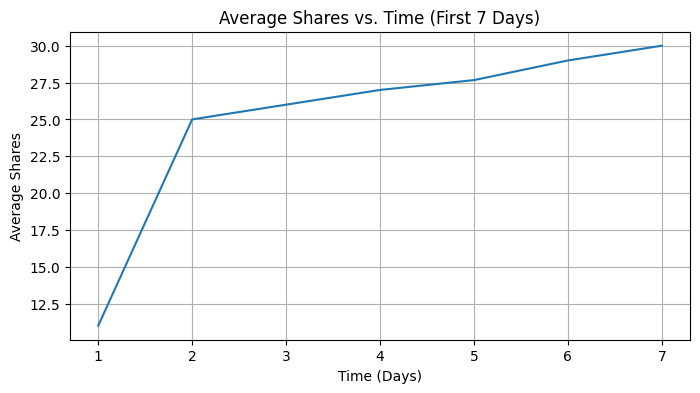

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average shares per day (time)
daily_avg_shares = df1.groupby('time')['shares'].mean().reset_index()

# Filter for the first 7 days
daily_avg_shares_7_days = daily_avg_shares[daily_avg_shares['time'] <= 7]

# Plotting
plt.figure(figsize=(8, 4))
sns.lineplot(x='time', y='shares', data=daily_avg_shares_7_days)
plt.title('Average Shares vs. Time (First 7 Days)')
plt.xlabel('Time (Days)')
plt.ylabel('Average Shares')
plt.grid(True)
plt.xticks(daily_avg_shares_7_days['time'])
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model re-fitted successfully for plotting 'sf' and 'sf2'.


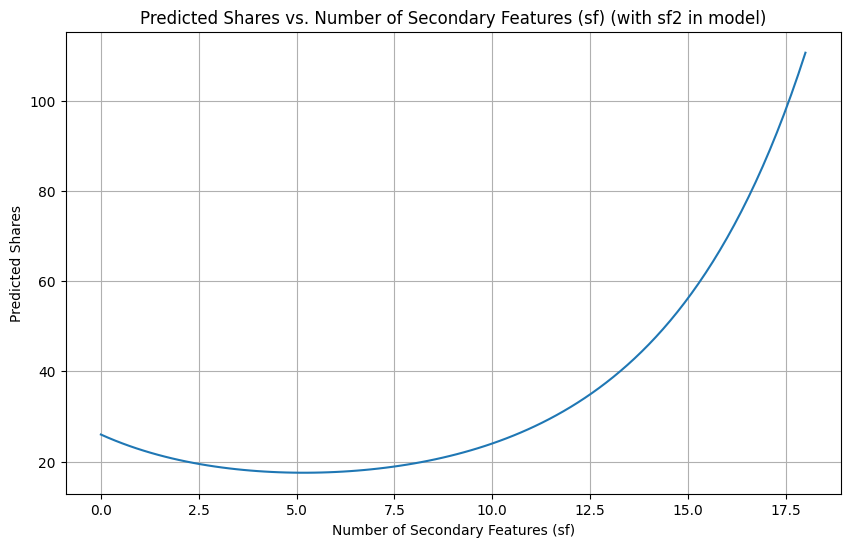

In [48]:
#Predicted Shares vs. Number of Secondary Features (sf)
import matplotlib.pyplot as plt
import seaborn as sns

# The X_var from the model including sf and sf2
X_var_with_sf2 = ['time', 'logwc','pf', 'saturation', 'post_interval', 'revenue', 'page active', 'sf', 'sf2']

# Re-create data_for_share_model and scaler that includes 'sf' and 'sf2'
Y_shares = df1['shares']
X_shares_with_sf2 = df1[X_var_with_sf2]

data_for_shares_model_with_sf2 = pd.concat([Y_shares, X_shares_with_sf2], axis=1)
data_for_shares_model_with_sf2 = data_for_shares_model_with_sf2.dropna(subset=['shares'] + X_var_with_sf2)
data_for_shares_model_with_sf2['shares'] = data_for_shares_model_with_sf2['shares'].astype(float).astype(int)

Y_clear_with_sf2 = data_for_shares_model_with_sf2['shares']
X_clear_with_sf2 = data_for_shares_model_with_sf2[X_var_with_sf2]

# Re-initialize and fit scaler for the model with sf and sf2
scaler_with_sf2 = StandardScaler()
X_scaled_with_sf2 = scaler_with_sf2.fit_transform(X_clear_with_sf2)
X_clear_with_sf2 = pd.DataFrame(X_scaled_with_sf2, columns=X_var_with_sf2, index=X_clear_with_sf2.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear_with_sf2 = sm.add_constant(X_clear_with_sf2, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_shares_with_sf2 = X_clear_with_sf2
try:
    zinb_cmodel_with_sf2 = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear_with_sf2, exog=X_clear_with_sf2, exog_infl=infl_shares_with_sf2)
    try:
        start_params_with_sf2 = zinb_cmodel_with_sf2.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        start_params_with_sf2 = np.zeros(len(X_clear_with_sf2.columns) * 2 + 1)
    zinb_shares_results_with_sf2 = zinb_cmodel_with_sf2.fit(maxiter=1000, disp=False, start_params=start_params_with_sf2)
    print("Model re-fitted successfully for plotting 'sf' and 'sf2'.")
except Exception as e:
    print(f"An error occurred during re-fitting model for 'sf' and 'sf2' plotting: {e}")

# Get the original (unscaled) X_var for reference
original_X_with_sf2 = data_for_shares_model_with_sf2[X_var_with_sf2]

# Create a DataFrame for prediction
# We want to vary 'sf' and keep other variables at their mean, and calculate 'sf2'
sf_range_for_plot = np.linspace(original_X_with_sf2['sf'].min(), original_X_with_sf2['sf'].max(), 100)

# Create a dictionary to hold the mean values for other predictors
mean_values_with_sf2 = original_X_with_sf2.mean().to_dict()

# Create a list of prediction dataframes
prediction_dfs_with_sf2 = []
for val_sf in sf_range_for_plot:
    pred_data = mean_values_with_sf2.copy()
    pred_data['sf'] = val_sf # Set 'sf' to the current value
    pred_data['sf2'] = val_sf ** 2 # Calculate 'sf2' from 'sf'
    prediction_dfs_with_sf2.append(pd.DataFrame([pred_data]))

# Concatenate all prediction dataframes
X_pred_unscaled_with_sf2 = pd.concat(prediction_dfs_with_sf2, ignore_index=True)

# Ensure the order of columns in X_pred_unscaled_with_sf2 matches X_var_with_sf2 for scaling
X_pred_unscaled_with_sf2 = X_pred_unscaled_with_sf2[X_var_with_sf2]

# Scale the prediction data using the *same scaler* fitted to the original data including sf2
X_pred_scaled_with_sf2 = scaler_with_sf2.transform(X_pred_unscaled_with_sf2)
X_pred_scaled_with_sf2 = pd.DataFrame(X_pred_scaled_with_sf2, columns=X_var_with_sf2, index=X_pred_unscaled_with_sf2.index)

# Add constant to the scaled prediction data
X_pred_scaled_with_sf2 = sm.add_constant(X_pred_scaled_with_sf2, prepend=False)

# Make predictions using the model that includes sf and sf2
predicted_shares_with_sf2 = zinb_shares_results_with_sf2.predict(exog=X_pred_scaled_with_sf2, exog_infl=X_pred_scaled_with_sf2)

# Create a DataFrame for plotting
plot_df_with_sf2 = pd.DataFrame({'sf': sf_range_for_plot, 'Predicted Shares': predicted_shares_with_sf2})

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(x='sf', y='Predicted Shares', data=plot_df_with_sf2)
plt.title('Predicted Shares vs. Number of Secondary Features (sf) (with sf2 in model)')
plt.xlabel('Number of Secondary Features (sf)')
plt.ylabel('Predicted Shares')
plt.grid(True)
plt.show()

In [49]:
variables = ['time', 'logwc', 'saturation', 'post_interval', 'revenue', 'page active']

# Get coefficients from zinb_share_results.params
coefficients = {var: zinb_shares_results.params[var] for var in variables}

# Get mean values from mean_values_with_sf2
means = {var: mean_values_with_sf2[var] for var in variables}

# Calculate the sum of products
sum_of_products = sum(coefficients[var] * means[var] for var in variables)

print(f"Coefficients: {coefficients}")
print(f"Mean values: {means}")
print(f"Sum of (coefficient * mean) for selected variables: {sum_of_products}")
b=zinb_shares_results.params['const']+sum_of_products
print(b)

Coefficients: {'time': np.float64(0.009911033891437089), 'logwc': np.float64(-0.00560805560344264), 'saturation': np.float64(0.0038055573934918053), 'post_interval': np.float64(-0.0013367732799146655), 'revenue': np.float64(-0.02166768932701397), 'page active': np.float64(0.026176239975828606)}
Mean values: {'time': 383.23824737562757, 'logwc': 3.380158051854861, 'saturation': 56.933363760839796, 'post_interval': 3.584664536741214, 'revenue': 4.136437627695116, 'page active': 5749.580556823368}
Sum of (coefficient * mean) for selected variables: 154.4039758138871
158.06912559088804


### Quantile Regression Analysis for Facebook Shares

We will now perform Quantile Regression to understand how the relationship between the independent variables and 'shares' changes across different quantiles of the 'shares' distribution. This is particularly useful for identifying factors that influence low, medium, and high share counts differently.

We will analyze the 50th (median), 70th, and 90th percentiles using the `statsmodels.formula.api.QuantReg` method.

In [50]:
# Define the formula for the quantile regression model
# Using the same predictors as the ZINB model for consistency
formula = 'shares ~ pf + sf + sf2 + time + logwc + saturation + post_interval + revenue + Q("page active")'

# List of quantiles to analyze
quantiles = [0.50, 0.70, 0.90]

print("Performing Quantile Regression for different quantiles...")

# Loop through each quantile and fit the model
for q in quantiles:
    print(f"\n--- Quantile Regression for {int(q*100)}th Percentile ---")
    # Fit the Quantile Regression model
    mod = smf.quantreg(formula, data=df1)
    res = mod.fit(q=q)

    # Print the summary of the results
    print(res.summary())

print("Quantile Regression analysis complete.")

Performing Quantile Regression for different quantiles...

--- Quantile Regression for 50th Percentile ---
                         QuantReg Regression Results                          
Dep. Variable:                 shares   Pseudo R-squared:              0.03277
Model:                       QuantReg   Bandwidth:                       9.832
Method:                 Least Squares   Sparsity:                        59.26
Date:                Tue, 18 Aug 2026   No. Observations:                 2191
Time:                        03:08:01   Df Residuals:                     2181
                                        Df Model:                            9
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           47.2440      4.691     10.070      0.000      38.044      56.444
pf                   0.9674      0.377      2.566      0.010       0.228       1.707


In [51]:
# Define the formula for the mixed-effects model
# 'shares' is the dependent variable
# 'pf + sf + sf2 + time + logwc + saturation + post_interval + revenue' are fixed effects
# 'page active' is specified as the grouping variable for random effects
formula = 'shares ~ pf + sf + sf2 + time + logwc + saturation + post_interval + revenue'

# Identify all columns used in the model, including the dependent variable and groups
model_columns = ['shares', 'time', 'logwc','pf','saturation', 'post_interval', 'revenue', 'page active','sf', 'sf2']

# Create a new DataFrame with only the relevant columns and drop rows with NaN values
# This ensures that 'data' and 'groups' have perfectly aligned indices and sizes
model_df = df1[model_columns].dropna()

# Fit the Mixed-Effects Model
# Pass the cleaned model_df and its 'page active' column for groups
print("Fitting Mixed-Effects Model for 'shares'...")
mixed_model = MixedLM.from_formula(formula, data=model_df, groups=model_df["page active"])

# Try to fit the model. It might take a moment.
# Using a robust covariance estimator can help with issues like heteroscedasticity
try:
    mixed_results = mixed_model.fit(maxiter=1000)
    print(mixed_results.summary())
except Exception as e:
    print(f"An error occurred during mixed-effects model fitting: {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Ensure the grouping variable has sufficient variation (more than one group).")
    print("3. Consider simplifying the random effects structure if convergence is an issue.")
    print("4. Try different optimization algorithms or increasing maxiter.")

Fitting Mixed-Effects Model for 'shares'...
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: shares     
No. Observations: 2191    Method:             REML       
No. Groups:       15      Scale:              617.3329   
Min. group size:  67      Log-Likelihood:     -10174.1604
Max. group size:  283     Converged:          Yes        
Mean group size:  146.1                                  
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      34.284    5.899  5.812 0.000 22.722 45.845
pf              0.469    0.318  1.477 0.140 -0.153  1.091
sf             -3.896    0.442 -8.822 0.000 -4.761 -3.030
sf2             0.419    0.042  9.978 0.000  0.337  0.502
time            0.001    0.002  0.634 0.526 -0.003  0.006
logwc          -1.964    1.445 -1.359 0.174 -4.796  0.869
saturation     -0.023    0.012 -1.879 

In [52]:
# Define dependent and independent variables for the GNB model
Y_shares_gnb = df1['shares']
X_var_gnb = ['time', 'logwc','pf','saturation', 'post_interval', 'revenue', 'page active','sf', 'sf2']
X_shares_gnb = df1[X_var_gnb]

# Combine and drop NaNs to ensure consistent data for the model
data_for_gnb_model = pd.concat([Y_shares_gnb, X_shares_gnb], axis=1)
data_for_gnb_model = data_for_gnb_model.dropna(subset=['shares'] + X_var_gnb)
data_for_gnb_model['shares'] = data_for_gnb_model['shares'].astype(float).astype(int)

Y_clear_gnb = data_for_gnb_model['shares']
X_clear_gnb = data_for_gnb_model[X_var_gnb]

# Scale the independent variables
scaler_gnb = StandardScaler()
X_scaled_gnb = scaler_gnb.fit_transform(X_clear_gnb)
X_clear_gnb = pd.DataFrame(X_scaled_gnb, columns=X_var_gnb, index=X_clear_gnb.index)

# Add a constant (intercept) to the independent variables
X_clear_gnb = sm.add_constant(X_clear_gnb, prepend=False)

try:
    print("Fitting Generalized Negative Binomial Regression model for 'shares'...")
    gnb_model = NegativeBinomial(endog=Y_clear_gnb, exog=X_clear_gnb)

    # Attempt to get default start_params if available or initialize with zeros
    try:
        # Try a quick fit for initial params, then perturb to avoid local optima
        start_params_gnb = gnb_model.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params_gnb = np.zeros(len(X_clear_gnb.columns) + 1) # exog_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    gnb_results = gnb_model.fit(maxiter=1000, disp=False, start_params=start_params_gnb)
    print(gnb_results.summary())
except Exception as e:
    print(f"An error occurred during GNB model fitting for 'shares': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables if not already done.")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'shares' is truly count data (non-negative integers).")

Fitting Generalized Negative Binomial Regression model for 'shares'...
                     NegativeBinomial Regression Results                      
Dep. Variable:                 shares   No. Observations:                 2191
Model:               NegativeBinomial   Df Residuals:                     2181
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                0.001550
Time:                        03:08:02   Log-Likelihood:                -7432.5
converged:                       True   LL-Null:                       -7444.0
Covariance Type:            nonrobust   LLR p-value:                  0.006017
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time             -0.0600      0.049     -1.232      0.218      -0.155       0.035
logwc            -0.0684      0.054     -1.259     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Hurdle Model for Facebook Shares

A hurdle model is a two-part model for count data with an excess of zeros. It consists of:

1.  **A binary model (e.g., Logistic Regression):** This models the probability of crossing the "hurdle" (i.e., having a non-zero count of shares).
2.  **A zero-truncated count model (e.g., Truncated Negative Binomial):** This models the count given that the hurdle has been crossed (i.e., only for posts with at least one share). Since `statsmodels` does not directly provide a zero-truncated negative binomial, we will use a standard Negative Binomial model on the subset of data where `shares > 0`.

We will use the same comprehensive set of predictors `['pf', 'sf', 'sf2', 'time', 'logwc', 'saturation', 'post_interval', 'revenue', 'page active']` that was used in the ZINB model.

In [53]:
# Define dependent and independent variables for the hurdle model
Y = df1['shares']
X_var = ['time', 'logwc','pf', 'saturation', 'post_interval', 'revenue', 'page active', 'sf', 'sf2']
X = df1[X_var]

# Combine and drop NaNs to ensure consistent data
data_for_hurdle_model = pd.concat([Y, X], axis=1)
data_for_hurdle_model = data_for_hurdle_model.dropna(subset=['shares'] + X_var)

# Convert shares to integer for count models
data_for_hurdle_model['shares'] = data_for_hurdle_model['shares'].astype(float).astype(int)

# --- Part 1: Hurdle Model (Binary: shares > 0) ---
print("\n--- Hurdle Model Part 1: Logistic Regression for Shares > 0 ---\n")

# Create a binary dependent variable: 1 if shares > 0, 0 otherwise
data_for_hurdle_model['has_shares'] = (data_for_hurdle_model['shares'] > 0).astype(int)

Y_binary = data_for_hurdle_model['has_shares']
X_binary = data_for_hurdle_model[X_var]

# Scale the independent variables for the binary part
scaler_binary = StandardScaler()
X_scaled_binary = scaler_binary.fit_transform(X_binary)
X_scaled_binary = pd.DataFrame(X_scaled_binary, columns=X_var, index=X_binary.index)

# Add a constant (intercept)
X_scaled_binary = sm.add_constant(X_scaled_binary, prepend=False)

try:
    logit_model = sm.Logit(Y_binary, X_scaled_binary)
    logit_results = logit_model.fit(disp=False, maxiter=1000)
    print(logit_results.summary())
except Exception as e:
    print(f"An error occurred during Logistic Regression: {e}")


--- Hurdle Model Part 1: Logistic Regression for Shares > 0 ---

                           Logit Regression Results                           
Dep. Variable:             has_shares   No. Observations:                 2191
Model:                          Logit   Df Residuals:                     2181
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                 0.02704
Time:                        03:08:02   Log-Likelihood:                -1474.2
converged:                       True   LL-Null:                       -1515.1
Covariance Type:            nonrobust   LLR p-value:                 6.667e-14
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time             -0.1365      0.050     -2.735      0.006      -0.234      -0.039
logwc            -0.1093      0.045     -2.405      0.01

In [54]:
# --- Part 2: Count Model (Negative Binomial for shares > 0) ---
print("\n--- Hurdle Model Part 2: Negative Binomial Regression for Shares (when Shares > 0) ---\n")

# Filter data to include only posts with shares > 0
df_positive_shares = data_for_hurdle_model[data_for_hurdle_model['shares'] > 0].copy()

Y_count = df_positive_shares['shares']
X_count = df_positive_shares[X_var]

# Scale the independent variables for the count part using a *new* scaler or the previous one fitted on the full dataset (depending on preference)
# For consistency, we will fit a new scaler on the positive shares data
scaler_count = StandardScaler()
X_scaled_count = scaler_count.fit_transform(X_count)
X_scaled_count = pd.DataFrame(X_scaled_count, columns=X_var, index=X_count.index)

# Add a constant (intercept)
X_scaled_count = sm.add_constant(X_scaled_count, prepend=False)

try:
    nb_model = sm.NegativeBinomial(Y_count, X_scaled_count)
    # Try to get initial parameters, and if not available, create a default
    try:
        start_params_nb = nb_model.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        start_params_nb = np.zeros(len(X_scaled_count.columns) + 1) # exog_params + alpha

    nb_results = nb_model.fit(disp=False, maxiter=1000, start_params=start_params_nb)
    print(nb_results.summary())
except Exception as e:
    print(f"An error occurred during Negative Binomial Regression: {e}")


--- Hurdle Model Part 2: Negative Binomial Regression for Shares (when Shares > 0) ---

                     NegativeBinomial Regression Results                      
Dep. Variable:                 shares   No. Observations:                 1158
Model:               NegativeBinomial   Df Residuals:                     1148
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                0.006693
Time:                        03:08:02   Log-Likelihood:                -5181.5
converged:                       True   LL-Null:                       -5216.5
Covariance Type:            nonrobust   LLR p-value:                 1.643e-11
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time              0.0091      0.019      0.471      0.637      -0.029       0.047
logwc            -0.0057      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Robustness Check for Negative Binomial Model

In [55]:
#Robustness Check for Negative Binomial Model
original_nbreg_model = sm.NegativeBinomial(Y_count, X_scaled_count)
original_nbreg_result = original_nbreg_model.fit(disp=False)

print("\n--- Original Negative Binomial Regression Results ---")
print(original_nbreg_result.summary())

# --- Robustness Check ---
# Randomly sample 90% of the data for the robustness check
sampled_df_positive_shares = df_positive_shares.sample(frac=0.9, random_state=42)

y_positive_sampled = sampled_df_positive_shares['shares']
X_positive_sampled = X_scaled_count.loc[sampled_df_positive_shares.index] # Ensure X aligns with sampled y

# Fit the Negative Binomial Regression model on the sampled data
nbreg_model_sampled = sm.NegativeBinomial(y_positive_sampled, X_positive_sampled)
nbreg_result_sampled = nbreg_model_sampled.fit(disp=False, maxiter=1000)

print("\n--- Robustness Check (90% Sampled Data) Negative Binomial Regression Results ---")
print(nbreg_result_sampled.summary())

# Create DataFrames for comparison
original_coef_pval = pd.DataFrame({
    'Original_Coef': original_nbreg_result.params,
    'Original_P_Value': original_nbreg_result.pvalues
})

sampled_coef_pval = pd.DataFrame({
    'Sampled_Coef': nbreg_result_sampled.params,
    'Sampled_P_Value': nbreg_result_sampled.pvalues
})

# Merge for side-by-side comparison
comparison_df = pd.merge(
    original_coef_pval, sampled_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) ---")
display(comparison_df.round(4))


--- Original Negative Binomial Regression Results ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                 shares   No. Observations:                 1158
Model:               NegativeBinomial   Df Residuals:                     1148
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                0.006693
Time:                        03:08:02   Log-Likelihood:                -5181.5
converged:                       True   LL-Null:                       -5216.5
Covariance Type:            nonrobust   LLR p-value:                 1.643e-11
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time              0.0091      0.019      0.472      0.637      -0.029       0.047
logwc            -0.0057      0.020     -0.289      0.773      -0.0

,Original_Coef,Original_P_Value,Sampled_Coef,Sampled_P_Value
alpha,0.3546,0.0000,0.3524,0.0000
const,3.6658,0.0000,3.6680,0.0000
logwc,-0.0057,0.7726,0.0074,0.7213
page active,0.0270,0.1777,0.0401,0.0601
pf,0.0166,0.3878,0.0182,0.3625
post_interval,-0.0011,0.9526,-0.0124,0.5114
revenue,-0.0218,0.2400,-0.0252,0.2009
saturation,0.0038,0.8357,0.0017,0.9280
sf,-0.3745,0.0000,-0.3535,0.0000
sf2,0.3434,0.0000,0.3269,0.0000


Robustness Check (90% Sampled Data) Logistic Regression Results

In [56]:
#Robustness Check (90% Sampled Data) Logistic Regression Results
original_logit_model = sm.Logit(Y_binary, X_scaled_binary)
original_logit_result = original_logit_model.fit_regularized(method='l1', alpha=0.1, disp=False)

print("\n--- Original Logistic Regression Results ---")
print(original_logit_result.summary())

# --- Robustness Check for Logistic Regression ---
# Randomly sample 90% of the data for the robustness check
sampled_df_logit = data_for_hurdle_model.sample(frac=0.9, random_state=42)

y_binary_sampled = sampled_df_logit['has_shares']
X_sampled = X_scaled_binary.loc[sampled_df_logit.index] # Ensure X aligns with sampled y_binary

# Fit the Logistic Regression model on the sampled data
logit_model_sampled = sm.Logit(y_binary_sampled, X_sampled)
logit_result_sampled = logit_model_sampled.fit_regularized(method='l1', alpha=0.1, disp=False)

print("\n--- Robustness Check (90% Sampled Data) Logistic Regression Results ---")
print(logit_result_sampled.summary())

# Create DataFrames for comparison
original_logit_coef_pval = pd.DataFrame({
    'Original_Coef': original_logit_result.params,
    'Original_P_Value': original_logit_result.pvalues
})

sampled_logit_coef_pval = pd.DataFrame({
    'Sampled_Coef': logit_result_sampled.params,
    'Sampled_P_Value': logit_result_sampled.pvalues
})

# Merge for side-by-side comparison
comparison_logit_df = pd.merge(
    original_logit_coef_pval, sampled_logit_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) for Logistic Regression ---")
display(comparison_logit_df.round(4))


--- Original Logistic Regression Results ---
                           Logit Regression Results                           
Dep. Variable:             has_shares   No. Observations:                 2191
Model:                          Logit   Df Residuals:                     2181
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                 0.02704
Time:                        03:08:03   Log-Likelihood:                -1474.2
converged:                       True   LL-Null:                       -1515.1
Covariance Type:            nonrobust   LLR p-value:                 6.670e-14
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time             -0.1363      0.050     -2.732      0.006      -0.234      -0.039
logwc            -0.1090      0.045     -2.398      0.016      -0.198      -

,Original_Coef,Original_P_Value,Sampled_Coef,Sampled_P_Value
const,0.1164,0.0077,0.1306,0.0045
logwc,-0.1090,0.0165,-0.1132,0.0182
page active,-0.2755,0.0000,-0.2624,0.0000
pf,0.0913,0.0458,0.0843,0.0766
post_interval,-0.2075,0.0007,-0.1967,0.0021
revenue,-0.0126,0.7735,-0.0071,0.8775
saturation,-0.0919,0.0360,-0.0782,0.0880
sf,-0.2286,0.0681,-0.2011,0.1163
sf2,0.3598,0.0075,0.3220,0.0179
time,-0.1363,0.0063,-0.1187,0.0252


Robustness Check for Negative Binomial Model with Clustered Robust Standard Errors

In [57]:
#Robustness Check for Negative Binomial Model with Clustered Robust Standard Errors
# --- Ensure X and y are set up for the full model
features = ['time','logwc','pf','saturation','post_interval','revenue','page active','sf','sf2']

y = df1['shares']
X = df1[features]

X = sm.add_constant(X)

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
X = X.fillna(X.mean())

constant_cols = [col for col in X.columns if col != 'const' and X[col].nunique() <= 1]
if constant_cols:
    X = X.drop(columns=constant_cols)

df_positive_likes = df1[df1['shares'] > 0]
y_positive = df_positive_likes['shares']
X_positive = X.loc[df_positive_likes.index]

# --- Original Negative Binomial Model with Clustered Robust Standard Errors ---
original_nbreg_model_cluster = sm.NegativeBinomial(y_positive, X_positive)
original_nbreg_result_cluster = original_nbreg_model_cluster.fit(
    disp=False, maxiter=1000,
    cov_type='cluster', cov_kwds={'groups': df_positive_likes['page active']}
)

print("\n--- Original Negative Binomial Regression Results (Clustered Robust SE) ---")
print(original_nbreg_result_cluster.summary())

# --- Robustness Check (90% Sampled Data) with Clustered Robust Standard Errors ---
sampled_df_positive_likes = df_positive_likes.sample(frac=0.9, random_state=42)

y_positive_sampled = sampled_df_positive_likes['shares'] # Corrected: should be 'shares', not 'likes'
X_positive_sampled = X_positive.loc[sampled_df_positive_likes.index] # Ensure X aligns with sampled y

# Fit the Negative Binomial Regression model on the sampled data with clustered robust SE
nbreg_model_sampled_cluster = sm.NegativeBinomial(y_positive_sampled, X_positive_sampled)
nbreg_result_sampled_cluster = nbreg_model_sampled_cluster.fit(
    disp=False, maxiter=1000,
    cov_type='cluster', cov_kwds={'groups': sampled_df_positive_likes['page active']}
)

print("\n--- Robustness Check (90% Sampled Data) Negative Binomial Regression Results (Clustered Robust SE) ---")
print(nbreg_result_sampled_cluster.summary())

# --- Create DataFrames for comparison ---
original_cluster_coef_pval = pd.DataFrame({
    'Original_Cluster_Coef': original_nbreg_result_cluster.params,
    'Original_Cluster_P_Value': original_nbreg_result_cluster.pvalues
})

sampled_cluster_coef_pval = pd.DataFrame({
    'Sampled_Cluster_Coef': nbreg_result_sampled_cluster.params,
    'Sampled_Cluster_P_Value': nbreg_result_sampled_cluster.pvalues
})

# Merge for side-by-side comparison
comparison_cluster_df = pd.merge(
    original_cluster_coef_pval, sampled_cluster_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled with Clustered Robust SE) ---")
display(comparison_cluster_df.round(4))


--- Original Negative Binomial Regression Results (Clustered Robust SE) ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                 shares   No. Observations:                 1158
Model:               NegativeBinomial   Df Residuals:                     1148
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                -0.06649
Time:                        03:08:03   Log-Likelihood:                -5563.3
converged:                      False   LL-Null:                       -5216.4
Covariance Type:              cluster   LLR p-value:                     1.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.8212      0.140     27.342      0.000       3.547       4.095
time           1.858e-05   4.42e-05      0.42

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endo

,Original_Cluster_Coef,Original_Cluster_P_Value,Sampled_Cluster_Coef,Sampled_Cluster_P_Value
alpha,1.3677,0.1272,1.3664,0.1250
const,3.8212,0.0000,3.7329,0.0000
logwc,-0.0104,0.4443,0.0041,0.7913
page active,0.0000,0.3829,0.0000,0.2122
pf,-0.0005,0.9652,0.0001,0.9910
post_interval,-0.0005,0.9022,-0.0033,0.3723
revenue,-0.0072,0.4121,-0.0087,0.3781
saturation,0.0000,0.9497,-0.0001,0.8379
sf,-0.1004,0.0000,-0.0935,0.0000
sf2,0.0084,0.0000,0.0079,0.0000


In [58]:
# Robustness Check for Zero-Inflated Negative Binomial Model

# --- Original Zero-Inflated Negative Binomial Regression Model ---
# Using the variables from the most comprehensive ZINB model setup (cell _3d3yqNiC5BA)
Y_clear_zinb = data_for_shares_model_with_sf2['shares']
X_clear_zinb = X_clear_with_sf2 # This is the scaled X with constant from _3d3yqNiC5BA

try:
    original_zinb_model = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear_zinb, exog=X_clear_zinb, exog_infl=X_clear_zinb)
    # Attempt to get default start_params or initialize with zeros
    try:
        start_params_original_zinb = original_zinb_model.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        start_params_original_zinb = np.zeros(len(X_clear_zinb.columns) * 2 + 1)
    original_zinb_result = original_zinb_model.fit(maxiter=1000, disp=False, start_params=start_params_original_zinb)
    print("\n--- Original Zero-Inflated Negative Binomial Regression Results ---")
    print(original_zinb_result.summary())
except Exception as e:
    print(f"An error occurred during original ZINB model fitting: {e}")

# --- Robustness Check for Zero-Inflated Negative Binomial Regression ---
# Randomly sample 90% of the data for the robustness check
# Use data_for_share_model_with_sf2 which was used for the main ZINB model
sampled_df_zinb_check = data_for_shares_model_with_sf2.sample(frac=0.9, random_state=42)

y_zinb_sampled = sampled_df_zinb_check['shares']

# Prepare exogenous variables for the sampled data
# Use the same scaler (scaler_with_sf2 from ecee7edb) that was used for the original ZINB model
# The columns should be the same as X_var_with_sf2 from ecee7edb (and _3d3yqNiC5BA)
X_var_for_zinb = ['time', 'logwc','pf','saturation', 'post_interval', 'revenue', 'page active', 'sf', 'sf2']
X_zinb_sampled_unscaled = sampled_df_zinb_check[X_var_for_zinb]

# Re-fit scaler_with_sf2 on the full original data if it's not guaranteed to be in scope from ecee7edb
# This ensures consistency even if cells were run out of order
scaler_with_sf2_re_fit = StandardScaler()
scaler_with_sf2_re_fit.fit(data_for_shares_model_with_sf2[X_var_for_zinb])

X_zinb_sampled_scaled = scaler_with_sf2_re_fit.transform(X_zinb_sampled_unscaled)
X_zinb_sampled = pd.DataFrame(X_zinb_sampled_scaled, columns=X_var_for_zinb, index=X_zinb_sampled_unscaled.index)

# Add a constant (intercept) to the independent variables
X_zinb_sampled = sm.add_constant(X_zinb_sampled, prepend=False)

# Fit the Zero-Inflated Negative Binomial Regression model on the sampled data
try:
    zinb_model_sampled = sm.ZeroInflatedNegativeBinomialP(endog=y_zinb_sampled, exog=X_zinb_sampled, exog_infl=X_zinb_sampled)
    # Attempt to get initial parameters or initialize with zeros
    try:
        start_params_sampled_zinb = zinb_model_sampled.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        start_params_sampled_zinb = np.zeros(len(X_zinb_sampled.columns) * 2 + 1)
    zinb_result_sampled = zinb_model_sampled.fit(maxiter=1000, disp=False, start_params=start_params_sampled_zinb)
    print("\n--- Robustness Check (90% Sampled Data) Zero-Inflated Negative Binomial Regression Results ---")
    print(zinb_result_sampled.summary())
except Exception as e:
    print(f"An error occurred during sampled ZINB model fitting: {e}")


# Create DataFrames for comparison
original_zinb_coef_pval = pd.DataFrame({
    'Original_Coef': original_zinb_result.params,
    'Original_P_Value': original_zinb_result.pvalues
})

sampled_zinb_coef_pval = pd.DataFrame({
    'Sampled_Coef': zinb_result_sampled.params,
    'Sampled_P_Value': zinb_result_sampled.pvalues
})

# Merge for side-by-side comparison
comparison_zinb_df = pd.merge(
    original_zinb_coef_pval, sampled_zinb_coef_pval,
    left_index=True, right_index=True,
    how='outer'
)

print("\n--- Comparison of Coefficients and P-Values (Original vs. Sampled) for Zero-Inflated Negative Binomial Regression ---")
display(comparison_zinb_df.round(4))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



--- Original Zero-Inflated Negative Binomial Regression Results ---


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                            shares   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2181
Method:                                      MLE   Df Model:                            9
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                 0.01125
Time:                                   03:08:04   Log-Likelihood:                -6655.1
converged:                                  True   LL-Null:                       -6730.8
Covariance Type:                       nonrobust   LLR p-value:                 4.380e-28
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time              0.1366      0.050      2.736      0.006       0.039       0.234
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



--- Robustness Check (90% Sampled Data) Zero-Inflated Negative Binomial Regression Results ---
                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                            shares   No. Observations:                 1972
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     1962
Method:                                      MLE   Df Model:                            9
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                 0.01024
Time:                                   03:08:05   Log-Likelihood:                -6037.6
converged:                                  True   LL-Null:                       -6100.1
Covariance Type:                       nonrobust   LLR p-value:                 1.323e-22
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
infl

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


,Original_Coef,Original_P_Value,Sampled_Coef,Sampled_P_Value
alpha,0.3566,0.0000,0.3616,0.0000
const,3.6651,0.0000,3.6636,0.0000
inflate_const,-0.1179,0.0070,-0.1321,0.0041
inflate_logwc,0.1094,0.0162,0.1136,0.0179
inflate_page active,0.2760,0.0000,0.2629,0.0000
inflate_pf,-0.0917,0.0450,-0.0848,0.0754
inflate_post_interval,0.2078,0.0007,0.1970,0.0021
inflate_revenue,0.0127,0.7714,0.0072,0.8748
inflate_saturation,0.0922,0.0357,0.0784,0.0873
inflate_sf,0.2311,0.0658,0.2036,0.1126


### Poisson Hurdle Regression Model

This section implements a two-part Poisson Hurdle model to account for the excess zeros in the 'shares' variable.

1.  **Part 1: Binary Logistic Regression**
    Predicts the probability that `shares > 0` (i.e., a post receives at least one like) versus `shares = 0`.

2.  **Part 2: Zero-Truncated Poisson Regression**
    Predicts the number of `shares` given that `shares > 0`. This model only considers observations where `shares are positive.

The final prediction from the Hurdle model is the product of the probability from Part 1 and the expected value from Part 2.

In [59]:
# Define features for the Hurdle model (using the same as the last comprehensive model)
features = ['time', 'logwc','pf', 'saturation', 'post_interval', 'revenue', 'page active','sf', 'sf2']

# Prepare dependent and independent variables for the entire dataset
y_full = df1['shares']
X_full = df1[features]

# Ensure sf2 is calculated consistently
X_full['sf2'] = X_full['sf'] ** 2

# Add constant for statsmodels
X_full = sm.add_constant(X_full)

# Ensure all columns in X_full are numeric and handle NaNs
for col in X_full.columns:
    X_full[col] = pd.to_numeric(X_full[col], errors='coerce')
X_full = X_full.fillna(X_full.mean())

# Drop constant columns if any, excluding the 'const' column
constant_cols_full = [col for col in X_full.columns if col != 'const' and X_full[col].nunique() <= 1]
if constant_cols_full:
    print(f"Dropping constant or near-constant columns in full X: {constant_cols_full}")
    X_full = X_full.drop(columns=constant_cols_full)

# --- Part 1: Logistic Regression for Zero vs. Non-Zero shares ---
print("\n--- Fitting Logistic Regression for Zero vs. Non-Zero shares ---")
df1['has_shares'] = (df1['shares'] > 0).astype(int)
y_binary_full = df1['has_shares']

logit_model_hurdle = sm.Logit(y_binary_full, X_full)
logit_result_hurdle = logit_model_hurdle.fit_regularized(method='l1', alpha=0.1, disp=False)
print(logit_result_hurdle.summary())

# --- Part 2: Zero-Truncated Poisson Regression for Positive Likes Only ---
print("\n--- Fitting Zero-Truncated Poisson Regression for Positive shares Only ---")

# Filter data for positive 'shares' only (using the pre-existing df_positive_shares and X_positive)
df_positive_shares = df1[df1['shares'] > 0]
y_positive = df_positive_shares['shares']
X_positive = X_full.loc[df_positive_shares.index] # Use the prepared X_full and align with positive shares

# Zero-Truncated Poisson model
# To address AttributeError: module 'statsmodels.api' has no attribute 'discrete'
# we need to import statsmodels.discrete.discrete_model directly to access ZeroTruncatedPoisson.
import statsmodels.discrete.discrete_model as smdm

# Check if ZeroTruncatedPoisson is available in statsmodels.discrete.discrete_model
if hasattr(smdm, 'ZeroTruncatedPoisson'):
    ztp_model = smdm.ZeroTruncatedPoisson(y_positive, X_positive)
else:
    print("Warning: ZeroTruncatedPoisson not directly found in statsmodels.discrete.discrete_model.")
    print("Falling back to a standard Poisson model for positive values. Interpretation should be cautious.")
    ztp_model = sm.Poisson(y_positive, X_positive)

ztp_result_hurdle = ztp_model.fit(disp=False, maxiter=1000) # Increased maxiter for convergence
print(ztp_result_hurdle.summary())


/tmp/ipykernel_449/123762074.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_full['sf2'] = X_full['sf'] ** 2
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))



--- Fitting Logistic Regression for Zero vs. Non-Zero shares ---
                           Logit Regression Results                           
Dep. Variable:             has_shares   No. Observations:                 2191
Model:                          Logit   Df Residuals:                     2183
Method:                           MLE   Df Model:                            7
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:              -0.0002566
Time:                        03:08:05   Log-Likelihood:                -1515.5
converged:                       True   LL-Null:                       -1515.1
Covariance Type:            nonrobust   LLR p-value:                     1.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.9754      0.315      6.276      0.000       1.358       2.592
time                   0        nan        nan        na

### Heckman Two-Step Model for Facebook Shares

This section implements the Heckman two-step selection model to account for potential selection bias. The model consists of two main stages:

1.  **Selection Equation (Probit Model):** This models the probability that a post receives at least one share (`shares > 0`).
2.  **Outcome Equation (OLS Regression):** This models the number of shares for posts that received at least one share (`shares > 0`), incorporating a correction term (Inverse Mills Ratio) derived from the selection equation.

In [60]:
# --- Heckman Step 1: Probit Model for Selection Equation ---
print("\n--- Heckman Step 1: Probit Model for Selection (has_shares > 0) ---")

# Dependent variable: has_shares (from previous hurdle model preparation)
y_selection = df1['has_shares']

# Independent variables (X_full was prepared for the hurdle model and includes 'sf2' and 'const')
X_selection = X_full

# Fit the Probit model
probit_model = sm.Probit(y_selection, X_selection)
probit_results = probit_model.fit(disp=False, maxiter=1000)
print(probit_results.summary())

# Calculate predicted probabilities from the Probit model
predicted_probs = probit_results.predict(X_selection)

# Calculate the Inverse Mills Ratio (IMR)
# IMR = pdf(probit_score) / cdf(probit_score)
# probit_score = X_selection @ probit_results.params

# Make sure to handle cases where cdf is very close to 0 or 1 to avoid division by zero or infinity
# Use the probit_results.exposure which already handles cases when probit is near 0 or 1.

# Need to manually calculate IMR since statsmodels probit doesn't directly give IMR for a Heckman context
# Manual calculation from parameters and X values
lin_pred_probit = probit_results.predict(X_selection, linear=True)

# Import norm from scipy.stats for PDF and CDF functions
from scipy.stats import norm as scipy_norm

phi = scipy_norm.pdf(lin_pred_probit) # PDF of standard normal
PHI = scipy_norm.cdf(lin_pred_probit) # CDF of standard normal

# Avoid division by zero for IMR
IMR = np.where(PHI == 0, 0, phi / PHI)

# Add IMR to the original dataframe, aligning by index
df1['IMR'] = IMR


--- Heckman Step 1: Probit Model for Selection (has_shares > 0) ---
                          Probit Regression Results                           
Dep. Variable:             has_shares   No. Observations:                 2191
Model:                         Probit   Df Residuals:                     2181
Method:                           MLE   Df Model:                            9
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                 0.02674
Time:                        03:08:06   Log-Likelihood:                -1474.6
converged:                       True   LL-Null:                       -1515.1
Covariance Type:            nonrobust   LLR p-value:                 1.008e-13
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.2263      0.202      6.085      0.000       0.831       1.621
time             -0.0002   7.93e-05     -3.037      0

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:530: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


In [61]:
# --- Heckman Step 2: OLS Regression for Outcome Equation ---
print("\n--- Heckman Step 2: OLS Regression for Outcome (shares > 0) with IMR ---")

# Filter data to include only posts with shares > 0 (where the outcome is observed)
observed_df = df1[df1['shares'] > 0].copy()

# Dependent variable for the outcome equation
y_outcome = observed_df['shares']

# Independent variables for the outcome equation (including the constant)
# Use the same features as X_full, and add the calculated IMR
# Make sure to get the X values corresponding to the observed_df indices
X_outcome = X_full.loc[observed_df.index].copy()
X_outcome['IMR'] = observed_df['IMR']

# Fit the OLS model
ols_model = sm.OLS(y_outcome, X_outcome)
ols_results = ols_model.fit()
print(ols_results.summary())


--- Heckman Step 2: OLS Regression for Outcome (shares > 0) with IMR ---
                            OLS Regression Results                            
Dep. Variable:                 shares   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     9.575
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           1.89e-15
Time:                        03:08:06   Log-Likelihood:                -5267.3
No. Observations:                1158   AIC:                         1.056e+04
Df Residuals:                    1147   BIC:                         1.061e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [62]:
#CLUSTER WITH PERSON AND PLANTS

Y_share = df1['shares']
X_var = ['time','logwc','pf','saturation','post_interval','revenue','page active','person','plant','sf','sf2']
X_share = df1[X_var]

data_for_share_model = pd.concat([Y_share, X_share], axis=1)
data_for_share_model = data_for_share_model.dropna(subset=['shares'] + X_var)
data_for_share_model['shares'] = data_for_share_model['shares'].astype(float).astype(int)

Y_clear = data_for_share_model['shares']
X_clear = data_for_share_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_share = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_share)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_share_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_share_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                            shares   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2179
Method:                                      MLE   Df Model:                           11
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                 0.01143
Time:                                   03:08:07   Log-Likelihood:                -6653.8
converged:                                  True   LL-Null:                       -6730.8
Covariance Type:                       nonrobust   LLR p-value:                 2.345e-27
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time              0.1359      0.050      2.721      0.007       0.038       0.234
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


In [63]:
#THREE CLUSTER APPROACH

Y_share = df1['shares']
X_var = ['time','logwc','pf','saturation','post_interval','revenue','page active','sf','sf2','cluster2','cluster3']
X_share = df1[X_var]

data_for_share_model = pd.concat([Y_share, X_share], axis=1)
data_for_share_model = data_for_share_model.dropna(subset=['shares'] + X_var)
data_for_share_model['shares'] = data_for_share_model['shares'].astype(float).astype(int)

Y_clear = data_for_share_model['shares']
X_clear = data_for_share_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_share = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_share)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_share_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_share_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                            shares   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2179
Method:                                      MLE   Df Model:                           11
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                 0.01145
Time:                                   03:08:09   Log-Likelihood:                -6653.7
converged:                                  True   LL-Null:                       -6730.8
Covariance Type:                       nonrobust   LLR p-value:                 2.095e-27
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time              0.1363      0.050      2.731      0.006       0.038       0.234
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


In [64]:
df1['sfr2'] = df1['sfr'] ** 2
df1['sfr2'].head()

,sfr2
0,0
1,0
2,0
3,0
4,0


In [65]:
#REGRESSION MODEL WITH PRIMARY FEATURES

Y_share = df1['shares']
X_var = ['time','logwc','pfr','saturation','post_interval','revenue','page active']
X_share = df1[X_var]

data_for_share_model = pd.concat([Y_share, X_share], axis=1)
data_for_share_model = data_for_share_model.dropna(subset=['shares'] + X_var)
data_for_share_model['shares'] = data_for_share_model['shares'].astype(float).astype(int)

Y_clear = data_for_share_model['shares']
X_clear = data_for_share_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_share = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_share)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_share_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_share_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                            shares   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2183
Method:                                      MLE   Df Model:                            7
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                0.005387
Time:                                   03:08:10   Log-Likelihood:                -6694.6
converged:                                  True   LL-Null:                       -6730.8
Covariance Type:                       nonrobust   LLR p-value:                 4.567e-13
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time              0.1414      0.050      2.841      0.005       0.044       0.239
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


In [66]:
#REGRESSION MODEL WITH SECONDARY FEATURES

Y_share = df1['shares']
X_var = ['time','logwc','saturation','post_interval','revenue','page active','sfr']
X_share = df1[X_var]

data_for_share_model = pd.concat([Y_share, X_share], axis=1)
data_for_share_model = data_for_share_model.dropna(subset=['shares'] + X_var)
data_for_share_model['shares'] = data_for_share_model['shares'].astype(float).astype(int)

Y_clear = data_for_share_model['shares']
X_clear = data_for_share_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_share = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_share)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_share_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_share_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                            shares   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2183
Method:                                      MLE   Df Model:                            7
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                0.005524
Time:                                   03:08:11   Log-Likelihood:                -6693.6
converged:                                  True   LL-Null:                       -6730.8
Covariance Type:                       nonrobust   LLR p-value:                 1.932e-13
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time              0.1374      0.050      2.763      0.006       0.040       0.235
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


In [67]:
#REGRESSION MODEL WITH PRIMARY AND SECONDARY FEATURES

Y_share = df1['shares']
X_var = ['time','logwc','pfr','saturation','post_interval','revenue','page active','sfr','sfr2']
X_share = df1[X_var]

data_for_share_model = pd.concat([Y_share, X_share], axis=1)
data_for_share_model = data_for_share_model.dropna(subset=['shares'] + X_var)
data_for_share_model['shares'] = data_for_share_model['shares'].astype(float).astype(int)

Y_clear = data_for_share_model['shares']
X_clear = data_for_share_model[X_var]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clear)
X_clear = pd.DataFrame(X_scaled, columns=X_var, index=X_clear.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear = sm.add_constant(X_clear, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_share = X_clear
try:
    print("Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...")
    zinb_cmodel = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear, exog=X_clear, exog_infl=infl_share)

    # Try to get initial parameters, and if not available, create a default
    try:
        # Attempt to get default start_params if available or initialize with zeros
        # Add a small perturbation to avoid all zeros if default is None or problematic
        start_params = zinb_cmodel.fit(disp=False, maxiter=1).params * 0.1 # Try a quick fit for initial params
    except Exception:
        # Fallback to zeros if initial fit fails, ensuring correct size
        start_params = np.zeros(len(X_clear.columns) * 2 + 1) # x_params + infl_params + alpha

    # Increased maxiter for convergence and suppressed iteration output
    zinb_share_results = zinb_cmodel.fit(maxiter=1000, disp=False, start_params=start_params)
    print(zinb_share_results.summary())
except Exception as e:
    print(f"An error occurred during model fitting for 'comments': {e}")
    print("\nTroubleshooting tips:")
    print("1. Check for multicollinearity among independent variables.")
    print("2. Consider scaling the independent variables (e.g., using StandardScaler from sklearn.preprocessing).")
    print("3. Try different initial parameters for the optimizer (solver, start_params).")
    print("4. Ensure 'comments' is truly count data (non-negative integers) and has sufficient zeros to warrant ZINB.")
    print("5. Verify that there's enough variance in 'comments' for a Negative Binomial model (overdispersion).")

Fitting Zero-Inflated Negative Binomial Regression model for 'comments'...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                            shares   No. Observations:                 2191
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                     2181
Method:                                      MLE   Df Model:                            9
Date:                           Tue, 18 Aug 2026   Pseudo R-squ.:                 0.01072
Time:                                   03:08:12   Log-Likelihood:                -6658.7
converged:                                  True   LL-Null:                       -6730.8
Covariance Type:                       nonrobust   LLR p-value:                 1.351e-26
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
inflate_time              0.1386      0.050      2.776      0.005       0.041       0.236
inflate_lo

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -


### Predicted Shares vs. Secondary Features Removal (sfr)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model re-fitted successfully for plotting 'sfr' and 'sfr2'.


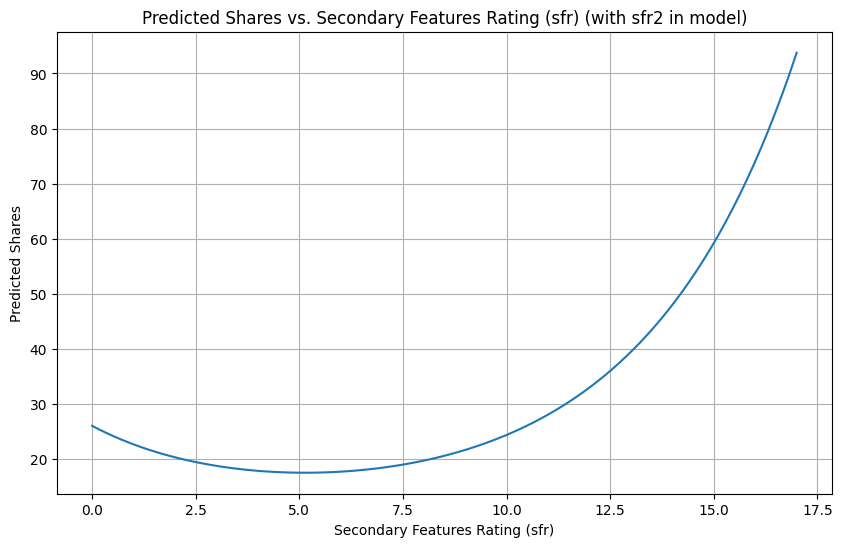

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# The X_var for the model including pfr, sfr and sfr2 (from cell TxNUmMAUDLWA)
X_var_with_sfr2 = ['time','logwc','pfr','saturation','post_interval','revenue','page active','sfr','sfr2']

# Re-create data_for_share_model and scaler that includes 'pfr', 'sfr' and 'sfr2'
Y_share = df1['shares']
X_share_with_sfr2 = df1[X_var_with_sfr2]

data_for_share_model_with_sfr2 = pd.concat([Y_share, X_share_with_sfr2], axis=1)
data_for_share_model_with_sfr2 = data_for_share_model_with_sfr2.dropna(subset=['shares'] + X_var_with_sfr2)
data_for_share_model_with_sfr2['shares'] = data_for_share_model_with_sfr2['shares'].astype(float).astype(int)

Y_clear_with_sfr2 = data_for_share_model_with_sfr2['shares']
X_clear_with_sfr2 = data_for_share_model_with_sfr2[X_var_with_sfr2]

# Re-initialize and fit scaler for the model with pfr, sfr and sfr2
scaler_with_sfr2 = StandardScaler()
X_scaled_with_sfr2 = scaler_with_sfr2.fit_transform(X_clear_with_sfr2)
X_clear_with_sfr2 = pd.DataFrame(X_scaled_with_sfr2, columns=X_var_with_sfr2, index=X_clear_with_sfr2.index)

# Add a constant (intercept) to the independent variables for the count part
X_clear_with_sfr2 = sm.add_constant(X_clear_with_sfr2, prepend=False)

# For the zero-inflation part, use the same independent variables for simplicity
infl_share_with_sfr2 = X_clear_with_sfr2
try:
    zinb_cmodel_with_sfr2 = sm.ZeroInflatedNegativeBinomialP(endog=Y_clear_with_sfr2, exog=X_clear_with_sfr2, exog_infl=infl_share_with_sfr2)
    try:
        start_params_with_sfr2 = zinb_cmodel_with_sfr2.fit(disp=False, maxiter=1).params * 0.1
    except Exception:
        start_params_with_sfr2 = np.zeros(len(X_clear_with_sfr2.columns) * 2 + 1)
    zinb_share_results_with_sfr2 = zinb_cmodel_with_sfr2.fit(maxiter=1000, disp=False, start_params=start_params_with_sfr2)
    print("Model re-fitted successfully for plotting 'sfr' and 'sfr2'.")
except Exception as e:
    print(f"An error occurred during re-fitting model for 'sfr' and 'sfr2' plotting: {e}")

# Get the original (unscaled) X_var for reference
original_X_with_sfr2 = data_for_share_model_with_sfr2[X_var_with_sfr2]

# Create a DataFrame for prediction
# We want to vary 'sfr' and keep other variables at their mean, and calculate 'sfr2'
sfr_range_for_plot = np.linspace(original_X_with_sfr2['sfr'].min(), original_X_with_sfr2['sfr'].max(), 100)

# Create a dictionary to hold the mean values for other predictors
mean_values_with_sfr2 = original_X_with_sfr2.mean().to_dict()

# Create a list of prediction dataframes
prediction_dfs_with_sfr2 = []
for val_sfr in sfr_range_for_plot:
    pred_data = mean_values_with_sfr2.copy()
    pred_data['sfr'] = val_sfr # Set 'sfr' to the current value
    pred_data['sfr2'] = val_sfr ** 2 # Calculate 'sfr2' from 'sfr'
    prediction_dfs_with_sfr2.append(pd.DataFrame([pred_data]))

# Concatenate all prediction dataframes
X_pred_unscaled_with_sfr2 = pd.concat(prediction_dfs_with_sfr2, ignore_index=True)

# Ensure the order of columns in X_pred_unscaled_with_sfr2 matches X_var_with_sfr2 for scaling
X_pred_unscaled_with_sfr2 = X_pred_unscaled_with_sfr2[X_var_with_sfr2]

# Scale the prediction data using the *same scaler* fitted to the original data including sfr2
X_pred_scaled_with_sfr2 = scaler_with_sfr2.transform(X_pred_unscaled_with_sfr2)
X_pred_scaled_with_sfr2 = pd.DataFrame(X_pred_scaled_with_sfr2, columns=X_var_with_sfr2, index=X_pred_unscaled_with_sfr2.index)

# Add constant to the scaled prediction data
X_pred_scaled_with_sfr2 = sm.add_constant(X_pred_scaled_with_sfr2, prepend=False)

# Make predictions using the model that includes sfr and sfr2
predicted_shares_with_sfr2 = zinb_share_results_with_sfr2.predict(exog=X_pred_scaled_with_sfr2, exog_infl=X_pred_scaled_with_sfr2)

# Create a DataFrame for plotting
plot_df_with_sfr2 = pd.DataFrame({'sfr': sfr_range_for_plot, 'Predicted Shares': predicted_shares_with_sfr2})

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(x='sfr', y='Predicted Shares', data=plot_df_with_sfr2)
plt.title('Predicted Shares vs. Secondary Features Rating (sfr) (with sfr2 in model)')
plt.xlabel('Secondary Features Rating (sfr)')
plt.ylabel('Predicted Shares')
plt.grid(True)
plt.show()

### Propensity Score Matching (PSM)

Propensity Score Matching (PSM) is a statistical matching technique that attempts to reduce bias in the estimation of treatment effects in observational studies. It does this by equating groups with respect to observed covariates that are thought to influence both the treatment assignment and the outcome.

Here are the general steps we will follow:
1.  **Define Treatment and Outcome**: We will define which variable represents the 'treatment' and which is the 'outcome'. For this example, we will consider `pf` (primary features) as the 'treatment' (e.g., whether a post has a primary feature, which we'll convert to a binary variable) and `shares` as the 'outcome'.
2.  **Select Covariates**: Choose relevant covariates that might influence both the 'treatment' and 'outcome'.
3.  **Estimate Propensity Scores**: Use a logistic regression model to predict the probability of receiving the treatment based on the selected covariates.
4.  **Perform Matching**: Match treated and control units based on their propensity scores.
5.  **Estimate Treatment Effect**: Calculate the average treatment effect on the treated (ATT) using the matched sample.

In [69]:
# 1. Define Treatment (pf_binary) and Outcome (shares)
# For demonstration, let's create a binary treatment variable from 'pf'
# We'll consider 'pf' > median(pf) as treated (1) and 'pf' <= median(pf) as control (0)
median_pf = df1['pf'].median()
df1['pf_binary_treatment'] = (df1['pf'] > median_pf).astype(int)

# Outcome variable
outcome_var = 'shares'

# Covariates - using a similar set as previous models
covariates = ['time', 'logwc', 'saturation', 'post_interval', 'revenue', 'page active']

# Create a working DataFrame for PSM, dropping NaNs in relevant columns
psm_df = df1[['pf_binary_treatment', outcome_var] + covariates].dropna()

#### 2. Estimate Propensity Scores using Logistic Regression

We will use Logistic Regression to model the probability of a post being in the 'treated' group (`pf_binary_treatment = 1`) based on the selected covariates. This probability is the propensity score.

In [70]:
# Prepare data for logistic regression
Y_psm = psm_df['pf_binary_treatment']
X_psm = psm_df[covariates]

# Scale covariates for logistic regression for better convergence
scaler_psm = StandardScaler()
X_psm_scaled = scaler_psm.fit_transform(X_psm)
X_psm_scaled = pd.DataFrame(X_psm_scaled, columns=covariates, index=X_psm.index)

# Add a constant (intercept) to the independent variables
X_psm_scaled = sm.add_constant(X_psm_scaled, prepend=False)

# Fit Logistic Regression model
print("Fitting Logistic Regression for Propensity Scores...")
logit_psm_model = sm.Logit(Y_psm, X_psm_scaled)
logit_psm_results = logit_psm_model.fit(disp=False, maxiter=1000)
print(logit_psm_results.summary())

# Get propensity scores
psm_df['propensity_score'] = logit_psm_results.predict(X_psm_scaled)
display(psm_df[['pf_binary_treatment', 'propensity_score']].head())

Fitting Logistic Regression for Propensity Scores...
                            Logit Regression Results                           
Dep. Variable:     pf_binary_treatment   No. Observations:                 2191
Model:                           Logit   Df Residuals:                     2184
Method:                            MLE   Df Model:                            6
Date:                 Tue, 18 Aug 2026   Pseudo R-squ.:                0.001730
Time:                         03:08:15   Log-Likelihood:                -1507.4
converged:                        True   LL-Null:                       -1510.0
Covariance Type:             nonrobust   LLR p-value:                    0.5152
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
time              0.0269      0.046      0.582      0.560      -0.064       0.117
logwc            -0.0367      0.045     -0.824      0.410    

,pf_binary_treatment,propensity_score
0,0,0.457715
1,0,0.465372
2,0,0.465125
3,0,0.454440
4,0,0.446791


#### 3. Perform Matching (Nearest Neighbor Matching)

We will now match each treated unit with one or more control units that have the closest propensity scores. For simplicity, we'll use a basic nearest-neighbor matching approach without replacement.

In [71]:
# Separate treated and control groups
treated = psm_df[psm_df['pf_binary_treatment'] == 1].copy()
control = psm_df[psm_df['pf_binary_treatment'] == 0].copy()

# Initialize a list to store matched control indices
matched_control_indices = []

# Iterate through each treated unit and find the closest control unit
# This is a simplified nearest-neighbor matching without replacement
# For more robust matching, consider libraries like 'patsy' or specialized PSM packages
for t_idx, t_row in treated.iterrows():
    # Calculate absolute difference in propensity scores
    diff = np.abs(control['propensity_score'] - t_row['propensity_score'])

    # Find the index of the control unit with the minimum difference
    # Ensure we don't match with controls already used if doing matching without replacement
    min_diff_idx = diff.idxmin()

    # Add the matched control index
    matched_control_indices.append(min_diff_idx)

    # Remove the matched control from the control pool to avoid replacement
    control = control.drop(min_diff_idx)

# Create the matched DataFrame
matched_treated = treated.copy()
matched_control = psm_df.loc[matched_control_indices].copy()

# Combine matched treated and control groups
matched_df = pd.concat([matched_treated, matched_control])

print(f"Original number of treated units: {len(treated)}")
print(f"Original number of control units: {len(psm_df) - len(treated)}")
print(f"Number of matched treated units: {len(matched_treated)}")
print(f"Number of matched control units: {len(matched_control)}")

display(matched_df.head())

Original number of treated units: 998
Original number of control units: 1193
Number of matched treated units: 998
Number of matched control units: 998


,pf_binary_treatment,shares,time,logwc,saturation,post_interval,revenue,page active,propensity_score
1193,1,34.0,30,4.488636,19,2,4.403935,2880,0.416307
1194,1,32.0,63,2.772589,20,1,7.251202,6333,0.431941
1195,1,31.0,74,4.043051,132,2,7.863775,5402,0.461800
1196,1,25.0,90,2.772589,15,2,7.267200,6333,0.429367
1197,1,0.0,108,4.836282,157,3,3.644220,6276,0.481955


#### 4. Estimate Average Treatment Effect on the Treated (ATT)

Finally, we will estimate the average treatment effect on the treated by comparing the outcome variable (`shares`) between the matched treated and control groups.

In [72]:
# Calculate the average outcome for treated and control in the matched sample
mean_outcome_treated = matched_treated[outcome_var].mean()
mean_outcome_control = matched_control[outcome_var].mean()

# Calculate the Average Treatment Effect on the Treated (ATT)
att = mean_outcome_treated - mean_outcome_control

print(f"Mean {outcome_var} for matched treated group: {mean_outcome_treated:.2f}")
print(f"Mean {outcome_var} for matched control group: {mean_outcome_control:.2f}")
print(f"\nAverage Treatment Effect on the Treated (ATT): {att:.2f}")

# For a more rigorous analysis, you would typically perform statistical tests
# (e.g., t-test) on the ATT and check for balance in covariates after matching.

Mean shares for matched treated group: 21.68
Mean shares for matched control group: 19.58

Average Treatment Effect on the Treated (ATT): 2.10


/tmp/ipykernel_449/933290787.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_name', y='engagement_intensity', data=avg_engagement_per_day, palette='viridis')


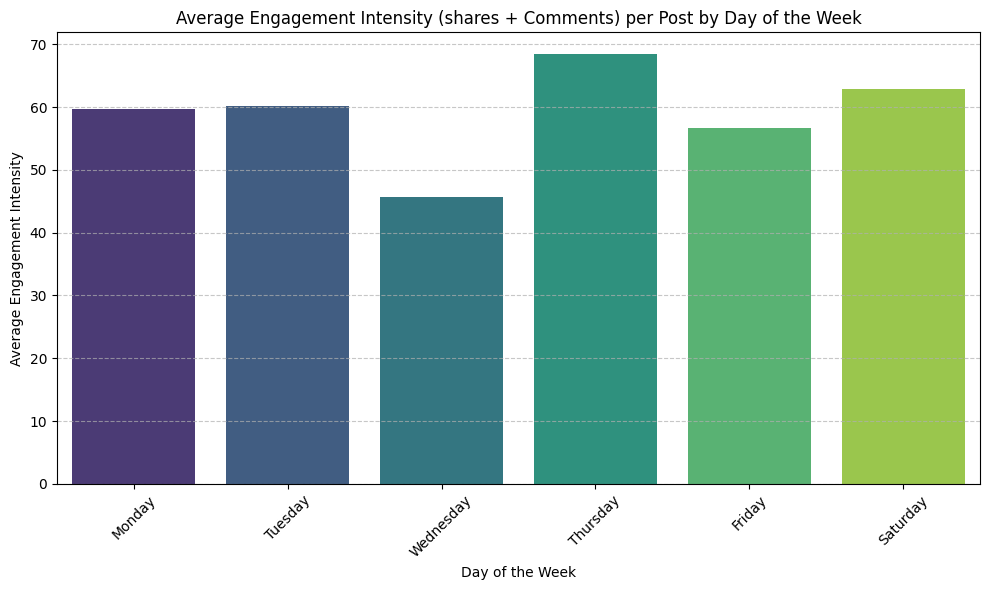

In [73]:
# Calculate engagement intensity (likes + comments)
df1['engagement_intensity'] = df1['shares'] + df1['comments']

# Ensure 'start date' is in datetime format
df1['start date'] = pd.to_datetime(df1['start date'], format='%d-%m-%Y')

# Extract the day of the week (Monday=0, Sunday=6)
df1['day_of_week'] = df1['start date'].dt.dayofweek

# Group by day of the week and calculate the mean of 'engagement_intensity'
avg_engagement_per_day = df1.groupby('day_of_week')['engagement_intensity'].mean().reset_index()

# Map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_engagement_per_day['day_name'] = avg_engagement_per_day['day_of_week'].map(lambda x: day_names[x])

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='day_name', y='engagement_intensity', data=avg_engagement_per_day, palette='viridis')
plt.title('Average Engagement Intensity (shares + Comments) per Post by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Engagement Intensity')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Predicted Shares vs. Unit Cost 'e'

b_coef_shares: 164.0496
beta_shares: 0.0160
zeta_shares: -0.3586
eta_shares: 0.2996


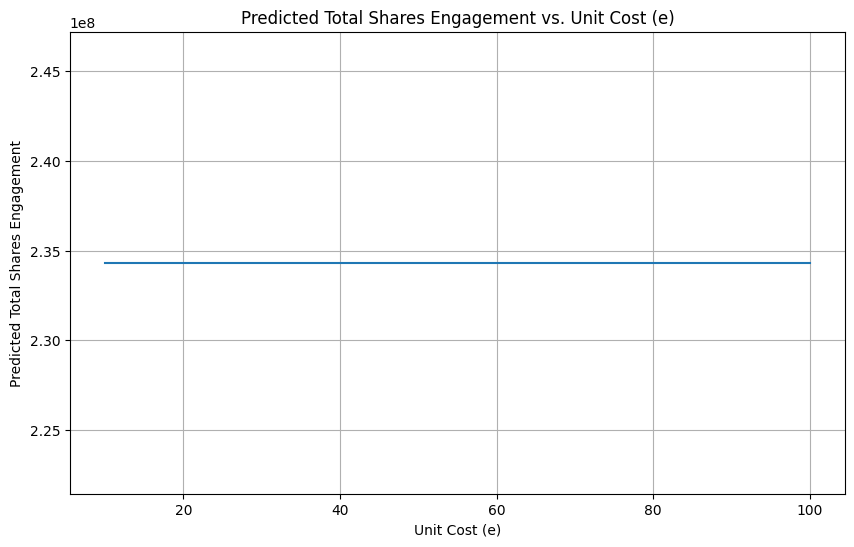

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a range of 'e' values for plotting
e_values = np.arange(10, 101, 10)

# Regression parameters for Facebook Shares (Table 2 & Table EC.35) are already set up in hfJKDkBxKHLQ
# b_coef, beta, zeta, eta are available from `zinb_shares_results` in previous cells
# Let's ensure we use the 'b' and coefficients from the zinb_shares_results that includes sf and sf2.
# The relevant coefficients for shares are available from cell '-IAF8XwmIxnB' and 'zinb_shares_results' from cell '_3d3yqNiC5BA'

# Recalculate 'b' using the zinb_shares_results from the model with pf, sf, sf2 (cell _3d3yqNiC5BA)
variables_for_b_coef_shares = ['time','logwc','pf','saturation','post_interval','revenue','page active','sf','sf2']
mean_values_all_shares = df1[variables_for_b_coef_shares].mean().to_dict()

coefficients_count_shares = {var: zinb_shares_results.params[var] for var in variables_for_b_coef_shares}
sum_of_products_shares = sum(coefficients_count_shares[var] * mean_values_all_shares[var] for var in variables_for_b_coef_shares)
b_coef_shares = zinb_shares_results.params['const'] + sum_of_products_shares

beta_shares = zinb_shares_results.params['pf']
zeta_shares = zinb_shares_results.params['sf']
eta_shares = zinb_shares_results.params['sf2']

print(f"b_coef_shares: {b_coef_shares:.4f}")
print(f"beta_shares: {beta_shares:.4f}")
print(f"zeta_shares: {zeta_shares:.4f}")
print(f"eta_shares: {eta_shares:.4f}")

results_shares = []

# Re-initialize q, u2, and mu_m to their correct values for faas_case_2 as they might have been overwritten.
q = [3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2]  # Mandatory primary features for each day
u2 = 18  # Upper bound for secondary features
mu_m = 1.0 # Relative weight for engagement type

for current_e in e_values:
    result_share_eng = faas_case_2(
        b_coef=b_coef_shares,
        beta=beta_shares,
        zeta=zeta_shares,
        eta=eta_shares,
        a=a,
        e=current_e,
        c_f=c_f,
        budget=budget,
        q=q,
        u2=u2,
        mu_m=mu_m,
        weights=weights,
        scale_factor=scale_factor
    )
    results_shares.append({'e': current_e, 'total_engagement_shares': result_share_eng['total_engagement']})

results_shares_df = pd.DataFrame(results_shares)

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(x='e', y='total_engagement_shares', data=results_shares_df)
plt.title('Predicted Total Shares Engagement vs. Unit Cost (e)')
plt.xlabel('Unit Cost (e)')
plt.ylabel('Predicted Total Shares Engagement')
plt.grid(True)
plt.show()

In [75]:
import math

def produce_table_ec40():
    # Empirical regression parameters (Table 2 & Table EC.35)
    # Shares (m=2)
    b2, beta2, zeta2, eta2 = 2.7067, -0.0500, -0.1012, 0.0098
    # Comments (m=3)
    b3, beta3, zeta3, eta3 = 3.3796, 0.0055, -0.1224, 0.0106

    scale_factor = 5000.0
    u2 = 18
    a = 20.0
    budget = 10000.0
    c_f = 0.0

    # Engagement weights
    mu2, mu3 = 0.7, 0.3

    # Days setup (K = 14)
    q = [3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2]
    weights = [10, 12, 16, 14, 16, 14, 10, 10, 12, 16, 14, 16, 14, 10]
    K = len(weights)

    # Precompute g_2j and g_3j lookup tables
    g2 = [(b2 + zeta2 * j + eta2 * (j**2)) * scale_factor for j in range(u2 + 1)]
    g3 = [(b3 + zeta3 * j + eta3 * (j**2)) * scale_factor for j in range(u2 + 1)]

    # Sort days by engagement weights
    indexed_weights = sorted(enumerate(weights), key=lambda x: x[1], reverse=True)

    print(f"{'e':<6}{'Optimal U':<12}{'Weighted Engagement':<22}{'Leftover Budget':<16}")
    print("=" * 56)

    for e in [20, 30, 40, 50, 60, 70, 80, 90]:
        best_engagement = -1.0
        best_U = 0
        best_leftover = 0.0

        # Search over all effort bounds U
        for U in range(u2 + 1):
            cost_primary = a * sum(q)
            b_prime = budget - cost_primary - (e * U) - c_f

            if b_prime < 0:
                continue

            f_k = [0] * K

            # Greedy allocation to max-weighted days
            for day_idx, w in indexed_weights:
                max_r = 0
                for r in range(U, -1, -1):
                    if r * a <= b_prime:
                        max_r = r
                        break
                f_k[day_idx] = max_r
                b_prime -= max_r * a

            # Compute total weighted engagement
            total_eng = 0.0
            for k in range(K):
                x2_k = (beta2 * scale_factor * q[k]) + g2[f_k[k]]
                x3_k = (beta3 * scale_factor * q[k]) + g3[f_k[k]]
                combined_x = (mu2 * x2_k) + (mu3 * x3_k)
                total_eng += weights[k] * combined_x

            if total_eng > best_engagement:
                best_engagement = total_eng
                best_U = U
                best_leftover = b_prime

        print(f"{e:<6}{best_U:<12}{best_engagement:<22.2f}{best_leftover:<16.2f}")

if __name__ == "__main__":
    produce_table_ec40()

e     Optimal U   Weighted Engagement   Leftover Budget 
20    18          3810375.50            3900.00         
30    18          3810375.50            3720.00         
40    18          3810375.50            3540.00         
50    18          3810375.50            3360.00         
60    18          3810375.50            3180.00         
70    18          3810375.50            3000.00         
80    18          3810375.50            2820.00         
90    18          3810375.50            2640.00         


In [76]:
import math

def produce_table_ec42():
    # Empirical regression parameters (Table 2 & Table EC.35)
    # Shares (m=2)
    b2, beta2, zeta2, eta2 = 2.7067, -0.0500, -0.1012, 0.0098
    # Comments (m=3)
    b3, beta3, zeta3, eta3 = 3.3796, 0.0055, -0.1224, 0.0106

    scale_factor = 5000.0
    u2 = 18
    a = 20.0
    budget = 10000.0
    c_f = 0.0

    # Engagement weights
    mu2, mu3 = 0.7, 0.3

    # Primary features (q_k)
    q = [3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2]

    # REVISED Day weights from Table EC.41 (Thursday & Friday weighted higher)
    weights = [10, 12, 14, 14, 16, 16, 10, 10, 12, 14, 14, 16, 16, 10]
    K = len(weights)

    # Precompute lookup tables
    g2 = [(b2 + zeta2 * j + eta2 * (j**2)) * scale_factor for j in range(u2 + 1)]
    g3 = [(b3 + zeta3 * j + eta3 * (j**2)) * scale_factor for j in range(u2 + 1)]

    # Sort days by engagement weights (descending)
    indexed_weights = sorted(enumerate(weights), key=lambda x: x[1], reverse=True)

    print(f"{'e':<6}{'Optimal U':<12}{'Weighted Engagement':<22}{'Leftover Budget':<16}")
    print("=" * 56)

    for e in [20, 30, 40, 50, 60, 70, 80, 90]:
        best_engagement = -1.0
        best_U = 0
        best_leftover = 0.0

        for U in range(u2 + 1):
            cost_primary = a * sum(q)
            b_prime = budget - cost_primary - (e * U) - c_f

            if b_prime < 0:
                continue

            f_k = [0] * K

            # Greedy allocation to max-weighted days
            for day_idx, w in indexed_weights:
                max_r = 0
                for r in range(U, -1, -1):
                    if r * a <= b_prime:
                        max_r = r
                        break
                f_k[day_idx] = max_r
                b_prime -= max_r * a

            # Compute total weighted engagement
            total_eng = 0.0
            for k in range(K):
                x2_k = (beta2 * scale_factor * q[k]) + g2[f_k[k]]
                x3_k = (beta3 * scale_factor * q[k]) + g3[f_k[k]]
                combined_x = (mu2 * x2_k) + (mu3 * x3_k)
                total_eng += weights[k] * combined_x

            if total_eng > best_engagement:
                best_engagement = total_eng
                best_U = U
                best_leftover = b_prime

        print(f"{e:<6}{best_U:<12}{best_engagement:<22.2f}{best_leftover:<16.2f}")

if __name__ == "__main__":
    produce_table_ec42()

e     Optimal U   Weighted Engagement   Leftover Budget 
20    18          3812043.00            3900.00         
30    18          3812043.00            3720.00         
40    18          3812043.00            3540.00         
50    18          3812043.00            3360.00         
60    18          3812043.00            3180.00         
70    18          3812043.00            3000.00         
80    18          3812043.00            2820.00         
90    18          3812043.00            2640.00         


In [77]:
import math

def produce_table_ec43():
    # Empirical regression parameters (Table 2 & Table EC.35)
    # Shares (m=2)
    b2, beta2, zeta2, eta2 = 2.7067, -0.0500, -0.1012, 0.0098
    # Comments (m=3)
    b3, beta3, zeta3, eta3 = 3.3796, 0.0055, -0.1224, 0.0106

    scale_factor = 5000.0
    u2 = 18
    a = 20.0
    budget = 10000.0
    c_f = 0.0

    # UNWEIGHTED engagement setup (mu2 = 1.0, mu3 = 1.0)
    mu2, mu3 = 1.0, 1.0

    # Primary features (q_k)
    q = [3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2]

    # Standard Day weights
    weights = [10, 12, 16, 14, 16, 14, 10, 10, 12, 16, 14, 16, 14, 10]
    K = len(weights)

    # Precompute g_2j and g_3j lookup tables
    g2 = [(b2 + zeta2 * j + eta2 * (j**2)) * scale_factor for j in range(u2 + 1)]
    g3 = [(b3 + zeta3 * j + eta3 * (j**2)) * scale_factor for j in range(u2 + 1)]

    # Sort days by engagement weights (descending)
    indexed_weights = sorted(enumerate(weights), key=lambda x: x[1], reverse=True)

    print(f"{'e':<6}{'Total Engagement':<20}{'Secondary Features on Posts (Days 1-14)':<45}")
    print("=" * 72)

    for e in [20, 30, 40, 50, 60, 70, 80, 90]:
        best_engagement = -1.0
        best_f_k = []

        for U in range(u2 + 1):
            cost_primary = a * sum(q)
            b_prime = budget - cost_primary - (e * U) - c_f

            if b_prime < 0:
                continue

            f_k = [0] * K

            # Greedy allocation to max-weighted days
            for day_idx, w in indexed_weights:
                max_r = 0
                for r in range(U, -1, -1):
                    if r * a <= b_prime:
                        max_r = r
                        break
                f_k[day_idx] = max_r
                b_prime -= max_r * a

            # Compute total unweighted engagement
            total_eng = 0.0
            for k in range(K):
                x2_k = (beta2 * scale_factor * q[k]) + g2[f_k[k]]
                x3_k = (beta3 * scale_factor * q[k]) + g3[f_k[k]]
                combined_x = x2_k + x3_k  # Direct sum
                total_eng += weights[k] * combined_x

            if total_eng > best_engagement:
                best_engagement = total_eng
                best_f_k = list(f_k)

        print(f"{e:<6}{int(round(best_engagement)):<20}{str(best_f_k):<45}")

if __name__ == "__main__":
    produce_table_ec43()

e     Total Engagement    Secondary Features on Posts (Days 1-14)      
20    7874617             [18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18]
30    7874617             [18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18]
40    7874617             [18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18]
50    7874617             [18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18]
60    7874617             [18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18]
70    7874617             [18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18]
80    7874617             [18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18]
90    7874617             [18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18]


In [78]:
def produce_table_ec45():
    scale_factor = 5000.0
    budget = 10000.0
    c_f = 0.0

    # User Base setup for Table EC.45
    v1 = 8000.0   # Instagram
    v2 = 10000.0  # Facebook
    V = v1 + v2

    # Compute z_lm weights
    z11 = 1.0 * (v1 / V)
    z22 = 0.7 * (v2 / V)
    z23 = 0.3 * (v2 / V)

    # Regression Parameters
    # Instagram Likes (l=1, m=1)
    b11, beta11, zeta11, eta11 = 1.6409, -0.0348, 0.0945, -0.0063
    # Facebook Shares (l=2, m=2)
    b22, beta22, zeta22, eta22 = 2.7067, -0.0500, -0.1012, 0.0098
    # Facebook Comments (l=2, m=3)
    b23, beta23, zeta23, eta23 = 3.3796, 0.0055, -0.1224, 0.0106

    u2_1 = 8   # Instagram concave limit
    u2_2 = 18  # Facebook upper bound

    # Precompute g_lmj tables
    g11 = [(b11 + zeta11 * j + eta11 * (j**2)) * scale_factor for j in range(u2_1 + 1)]
    g22 = [(b22 + zeta22 * j + eta22 * (j**2)) * scale_factor for j in range(u2_2 + 1)]
    g23 = [(b23 + zeta23 * j + eta23 * (j**2)) * scale_factor for j in range(u2_2 + 1)]

    q = [3, 4, 2, 2, 2, 1, 2, 2, 4, 6, 1, 2, 2, 2]
    weights = [10, 12, 16, 14, 16, 14, 10, 10, 12, 16, 14, 16, 14, 10]
    K = len(weights)

    for a in [20, 30, 40, 50]:
        print(f"\n==================== RESULTS FOR a = {a} ====================")
        print(f"{'e':<6}{'Instagram (Likes)':<20}{'Facebook (Shares & Comm)':<26}{'Total':<12}")
        print("-" * 64)

        for e in [20, 30, 40, 50, 60, 70, 80, 90]:
            best_total = -1.0
            best_ig_eng = 0.0
            best_fb_eng = 0.0

            # Grid search over U1 and U2
            for U1 in range(u2_1 + 1):
                for U2 in range(u2_2 + 1):
                    cost_primary = 2 * a * sum(q)
                    b_prime = budget - cost_primary - e * (U1 + U2) - 2 * c_f

                    if b_prime < 0:
                        continue

                    # Build all candidate platform-day assignments
                    candidates = []

                    # Instagram options
                    for k in range(K):
                        base_x = beta11 * scale_factor * q[k] + g11[0]
                        max_x = beta11 * scale_factor * q[k] + g11[U1]
                        gain = z11 * weights[k] * (max_x - base_x)
                        candidates.append(('IG', k, U1, gain, base_x, max_x))

                    # Facebook options
                    for k in range(K):
                        base_x2 = beta22 * scale_factor * q[k] + g22[0]
                        base_x3 = beta23 * scale_factor * q[k] + g23[0]
                        base_comb = z22 * base_x2 + z23 * base_x3

                        max_x2 = beta22 * scale_factor * q[k] + g22[U2]
                        max_x3 = beta23 * scale_factor * q[k] + g23[U2]
                        max_comb = z22 * max_x2 + z23 * max_x3

                        gain = weights[k] * (max_comb - base_comb)
                        candidates.append(('FB', k, U2, gain, base_comb, max_comb))

                    # Sort candidates by gain per feature cost
                    candidates.sort(key=lambda x: x[3], reverse=True)

                    f1 = [0] * K
                    f2 = [0] * K

                    # Greedy selection
                    for plt, k, target_f, gain, base_val, max_val in candidates:
                        cost = target_f * a
                        if cost <= b_prime and target_f > 0:
                            if plt == 'IG':
                                f1[k] = target_f
                            else:
                                f2[k] = target_f
                            b_prime -= cost

                    # Compute engagement
                    ig_eng = sum(z11 * weights[k] * (beta11 * scale_factor * q[k] + g11[f1[k]]) for k in range(K))
                    fb_eng = sum(weights[k] * (z22 * (beta22 * scale_factor * q[k] + g22[f2[k]]) +
                                               z23 * (beta23 * scale_factor * q[k] + g23[f2[k]])) for k in range(K))
                    total_eng = ig_eng + fb_eng

                    if total_eng > best_total:
                        best_total = total_eng
                        best_ig_eng = ig_eng
                        best_fb_eng = fb_eng

            print(f"{e:<6}{best_ig_eng:<20.0f}{best_fb_eng:<26.0f}{best_total:<12.0f}")

if __name__ == "__main__":
    produce_table_ec45()


==================== RESULTS FOR a = 20 ====================
e     Instagram (Likes)   Facebook (Shares & Comm)  Total       
----------------------------------------------------------------
20    779474              2116875                   2896349     
30    779474              2116875                   2896349     
40    779474              2116875                   2896349     
50    779474              2116875                   2896349     
60    779474              2116875                   2896349     
70    774322              2116875                   2891197     
80    766762              2116875                   2883637     
90    764018              2116875                   2880893     

==================== RESULTS FOR a = 30 ====================
e     Instagram (Likes)   Facebook (Shares & Comm)  Total       
----------------------------------------------------------------
20    678898              2080295                   2759193     
30    663442              20802